#### Institute of Data Capstone Project
# 📚 Books Don't Die, They Slow Down
##### Notebook 2 of 4 · Exploratory Data Analysis
##### Author: Mike Ee, [mikeee.co](https://mikeee.co)

Research Question
> What do 15 years of sales reveal about the client's demand mix, title lifecycles and revenue leakage?

## Table of Contents

1. [Setup](#setup)
2. [Load](#load)
3. [Data profiling](#profiling)
4. [Research scope and business questions](#scope)
5. [Figures](#figures)
6. [Conclusion](#conclusion)

<a id="setup"></a>
## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, re

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

In [2]:
# styling libraries
#   matplotx  for style: fonts, spines, grid, background
#   colorcet  for colour: perceptually uniform colormaps, greyscale/CVD-safe
import colorcet as cc
import matplotx
import matplotlib as mpl

In [3]:
# ── a. matplotx: tokyo_night ─────────────────────────────────────────────────
# matplotx exposes styles as flat dicts OR dicts-of-variants.
STYLE_NAME, STYLE_VARIANT = "tokyo_night", "night"

_obj = getattr(matplotx.styles, STYLE_NAME)
if isinstance(_obj, dict) and all(isinstance(v, dict) for v in _obj.values()):
    assert STYLE_VARIANT in _obj, (
        f"{STYLE_NAME} variants are {list(_obj)}: {STYLE_VARIANT!r} is not one"
    )                                    # guardrail: typos
    STYLE = _obj[STYLE_VARIANT]
else:
    STYLE = _obj

mpl.rcParams.update(STYLE)               # global, not `with plt.style.context()`

DARK = mpl.colors.rgb_to_hsv(
    mpl.colors.to_rgb(mpl.rcParams["figure.facecolor"]))[2] < 0.5
# ↑ measured; drives palette and annotation choices below

# ── b. colour registry for the measured background ──────────────────────────
CAT = [
    "#7AA2F7",   # blue      — tokyo_night's accent as default
    "#E0AF68",   # amber
    "#9ECE6A",   # green, desaturated
    "#BB9AF7",   # violet
    "#7DCFFF",   # cyan
    "#FF9E64",   # orange
    "#73DACA",   # teal
    "#C3A6FF",   # lilac
    "#B4F9F8",   # pale cyan
    "#D5A0C0",   # dusty rose  ← distinct from NEG; NEG stays reserved
]
CAT_ALT = cc.glasbey_light          # use when a cut exceeds 10 categories

# make the implicit path agree with the explicit one
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=CAT)
# ↑ without this, a plot that omits color= draws from tokyo_night's cycle
#   while its neighbour draws from CAT. Same chart type, different palette.

# sequential: ordered magnitude. On dark the ramp must run dark→bright or the
#   low end vanishes into the background.
SEQ      = cc.cm.bmy if DARK else cc.cm.CET_L17
SEQ_ALT  = cc.cm.fire if DARK else cc.cm.CET_L17_r

# diverging: meaningful midpoint. CET_D1A centres on WHITE, which on dark reads
#   as the brightest value and inverts the meaning. D13 centres dark.
DIV      = cc.cm.CET_D13 if DARK else cc.cm.CET_D1A

# neutrals, derived from the measured background rather than hardcoded
FG       = mpl.rcParams["text.color"]
GREY     = "#8A8FA3" if DARK else "#C4C4C4"   # sentinel / de-emphasised series
NEG      = "#F7768E" if DARK else "#C0392B"   # returns, credit notes, negatives
RULE     = "#565F89" if DARK else "#999999"   # event lines, reference rules

# ── c. display labels: never mutate `sales` ─────────────────────────────────
LABEL_COLOURS = {
    "Book sales":         CAT[0],
    "Services":           CAT[1],
    "Institutional bulk": CAT[2],
    "Ancillary":          GREY,
}
SENTINEL = "Not recorded"

FAMILY_COLOURS = {
    "Essays":              "#7AA2F7",   # light blue
    "Poetry":              "#E0AF68",   # amber
    "Short fiction":       "#9ECE6A",   # green
    "Life writing":        "#BB9AF7",   # violet
    "Long fiction":        "#FF9E64",   # orange
    "History and Culture": "#41A6B5",   # deep teal   ← dark vs Children & YA
    "Children & YA":       "#B4F9F8",   # pale cyan   ← light vs History
    "Education":           "#3D59A1",   # dark blue   ← dark vs Essays
    "Drama":               "#D5A0C0",   # dusty rose
    "— not recorded —":    GREY,
}

def pin_sentinel(df, sort_col="revenue"):
    """Sort real categories by size, pin the sentinel last regardless.
    Objective: absence of information must not out-rank real categories.
    Modify: sort_col="units" to rank by volume instead.
    """
    real  = df.drop(index=SENTINEL, errors="ignore").sort_values(sort_col, ascending=False)
    order = real.index.tolist() + ([SENTINEL] if SENTINEL in df.index else [])
    return df.reindex(order)

def trunc(s, n=38):
    """Chart-label safe string: strip embedded newlines and shorten.
    Modify: n down to ~28 for slide-scale legends.
    """
    s = " ".join(str(s).split())
    return s if len(s) <= n else s[: n - 1] + "…"

# ── d. era bands ─────────────────────────────────────────────────────────────
# Timestamps, not ints. axvspan(2011, 2015) on a datetime axis silently plots
# at epoch-nanosecond 2011: a band 6 microseconds wide at 1970. Invisible bug.
ERAS = [
    (pd.Timestamp("2011-08-01"), pd.Timestamp("2015-01-01"), "services-led"),
    (pd.Timestamp("2015-01-01"), pd.Timestamp("2020-01-01"), "book-led"),
    (pd.Timestamp("2020-01-01"), pd.Timestamp("2023-01-01"), "COVID"),
    (pd.Timestamp("2023-01-01"), pd.Timestamp("2026-08-01"), "post-COVID"),
]

def shade_eras(ax, eras=ERAS, label=True, y=0.97, alpha=None):
    """Alternating era bands behind the data. Call BEFORE plotting.
    Modify: alpha up if bands are invisible at slide scale; label=False when
      the same axis already carries EVENTS annotations (they collide).
    """
    alpha = alpha if alpha is not None else (0.10 if DARK else 0.07)
    tint  = "white" if DARK else "grey"
    for i, (x0, x1, name) in enumerate(eras):
        if i % 2 == 0:
            ax.axvspan(x0, x1, color=tint, alpha=alpha, zorder=0, linewidth=0)
        if label:
            mid = x0 + (x1 - x0) / 2          # valid for ints AND timestamps
            ax.text(mid, y, name, transform=ax.get_xaxis_transform(),
                    ha="center", va="top", fontsize=8, color=GREY)

# ── e. external events: context annotation only ─────────────────────────────
EVENTS = [
    (pd.Timestamp("2014-01-01"), "eBook adoption\nbroadens"),
    (pd.Timestamp("2020-04-01"), "COVID-19\ncircuit breaker"),
    (pd.Timestamp("2026-03-01"), "Culture Pass\nopens"),
]

def mark_events(ax, events=EVENTS, y=0.92, fontsize=8):
    """Dashed vertical rules and labels for the EVENTS list.
    Modify: pass a filtered list; three rules on a 12-month window is noise.
    """
    for x, name in events:
        ax.axvline(x, color=RULE, linestyle="--", linewidth=0.9, zorder=1)
        ax.text(x, y, f" {name}", transform=ax.get_xaxis_transform(),
                ha="left", va="top", fontsize=fontsize, color=RULE)

def tidy_event_labels(ax):
    """Left-align event labels, lift them above the data, nudge them off the rule."""
    for child in ax.get_children():
        if isinstance(child, mpl.text.Text):
            child.set_zorder(5)
            child.set_clip_on(False)
            child.set_horizontalalignment("left")
            child.set_multialignment("left")
            txt = child.get_text()
            if txt:
                child.set_text("\n".join(line.strip() for line in txt.split("\n")))
                x_pos, y_pos = child.get_position()
                if isinstance(x_pos, (pd.Timestamp, np.datetime64)):
                    child.set_position((x_pos + pd.Timedelta(days=25), y_pos))
        elif isinstance(child, mpl.lines.Line2D):
            child.set_zorder(5)

# ── f. baseline rcParams applied after style: deliberate overrides ──────────
mpl.rcParams.update({
    "figure.dpi":         110,
    "savefig.dpi":        200,
    "figure.figsize":     (10, 5),
    "axes.titlesize":     12,
    "axes.titleweight":   "bold",
    "axes.labelsize":     10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.frameon":     False,
    "lines.linewidth":    1.8,
    "figure.autolayout":  False,
})

print(f"style      : {STYLE_NAME}/{STYLE_VARIANT}  ·  dark={DARK}")
print(f"categorical: {len(CAT)} colours · first 5 {CAT[:5]}")
print("styling ready")

style      : tokyo_night/night  ·  dark=True
categorical: 10 colours · first 5 ['#7AA2F7', '#E0AF68', '#9ECE6A', '#BB9AF7', '#7DCFFF']
styling ready


<a id="load"></a>
## 2. Load

Data and filters come from `capstone.py`, the only reader of the filter contract built in notebook 1.

In [4]:
%load_ext autoreload
%autoreload 2

from capstone import *

df        = load_scoped()      # sales_scoped.parquet
bm        = load_master()      # book_master.csv, ISBN grain
sales     = df                 # alias used by the profiling cells
POP_TABLE = populations()
display(POP_TABLE[["lines", "units", "isbns", "months"]])

scoped   94,872 lines · 180 months · contract v1
master   640 ISBNs · 552 with genre · 632 commercially active


,lines,units,isbns,months
filter,,,,
composition,94872,653584.51,640,180
all,94872,653584.51,640,180
units_observable,94510,653584.51,640,180
demand,83346,541817.00,639,180
genre,81336,531424.00,552,180
net_revenue,90662,497985.00,640,180
returns,7316,-43832.00,491,177
price_vol,74990,456266.00,632,180
revenue_ts,83614,555279.00,639,180


In [5]:
print(f"contract v{CONTRACT['contract_version']} · "
      f"book_scope = {BOOK_SCOPE} · types {BOOK_TYPES}")
for k, v in FILTERS.items():
    print(f"  {k:<18} {v}")

assert "units_observable" in FILTERS, "filter contract is stale"
assert isinstance(FILTERS, dict), "FILTERS was rebound"

contract v1 · book_scope = book_scope == True · types ['Paperback', 'eBook']
  composition        index == index
  all                index == index
  units_observable   qty_sign != "null"
  demand             book_scope == True and line_role in ["sale","foc","unpriced"] and client_excluded == False
  genre              book_scope == True and line_role in ["sale","foc","unpriced"] and has_genre == True and client_excluded == False
  net_revenue        book_scope == True and qty_sign != "null" and client_excluded == False
  returns            book_scope == True and line_role == "return" and client_excluded == False
  price_vol          book_scope == True and line_role == "sale" and Qty > 0 and client_excluded == False
  revenue_ts         (book_scope == True or scope_reason in ["service", "institutional_bulk"]) and line_role != "return" and qty_sign != "null" and client_excluded == False


<a id="profiling"></a>
## 3. Data profiling

In [6]:
sales.dtypes

year_raw                                   int64
month_raw                                 object
FY                                        object
Invoice/CM #                              object
Item ID                                   object
Item Description                          object
Customer ID                               object
Name                                      object
Line Description                          object
Unit Price                               float64
Qty                                      float64
Amount                                   float64
FOC                                       object
Channel                                   object
Type                                      object
Item Description - alternative            object
date                              datetime64[ns]
ym                                     period[M]
quarter                                    int32
dow                                       object
isbn_key            

In [7]:
# ── filter helper + population registry ─────────────────────────────────────
F = FILTERS
q = lambda k: pop(k)

# POP is the ONLY source for a population count in a caption. Never type a
# literal into set_title(): captions must move when the population moves.
POP = {k: int(POP_TABLE.loc[k, "lines"]) for k in FILTERS}
POP_S = {k: f"{v:,}" for k, v in POP.items()}

for k, v in POP.items():
    print(f"  {k:<18} {v:>7,}")

# Asserts capable of failing on plausible data
assert POP["demand"] + POP["returns"] == POP["net_revenue"], \
    f"GROSS + returns != NET: {POP['demand']:,} + {POP['returns']:,}"
assert POP["genre"] <= POP["demand"],     "genre must be a subset of demand"
assert POP["price_vol"] <= POP["demand"], "price_vol must be a subset of demand"
assert POP["all"] == len(sales),          "identity filter is not identity"

  composition         94,872
  all                 94,872
  units_observable    94,510
  demand              83,346
  genre               81,336
  net_revenue         90,662
  returns              7,316
  price_vol           74,990
  revenue_ts          83,614


### 3.1 Cardinality

In [8]:
# Objective: which object columns are labels (low n) vs identifiers (high n)
card = (sales.select_dtypes(["object", "string", "category"])
             .nunique()
             .sort_values(ascending=False))
print("── cardinality ──")
print(card.to_string())

── cardinality ──
Invoice/CM #                      27717
Line Description                  15976
Item ID                             931
Item Description                    858
product_key                         778
Name                                747
Customer ID                         741
Item Description - alternative      656
isbn_key                            640
title                               444
author                              335
weight_g                            192
sub_category                        112
pub_year                             31
doc_type                             15
FY                                   15
month_raw                            12
genre                                11
subcat_family                        10
format                                8
dow                                   7
line_role                             6
Type                                  6
scope_reason                          5
line_category         

### 3.2 Defect checks

In [9]:
print("\n── defect 1: does `genre` leak client-excluded lines? ──")
leak = sales.query(
    f'{BOOK_SCOPE} and has_genre == True '
    'and line_role != "return" and client_excluded == True',
    engine="python")
print(f"lines in genre that demand excludes : {len(leak):,}")
# ↑ if 0, the filter is correct. The contract composes every book filter from
#   one BOOK_SCOPE string, so this probe is a regression test.

print("\n── defect 2: nullable boolean NAs ──")
for c in ["client_excluded", "culture_pass", "is_return", "is_foc",
          "is_credit_adj", "price_missing"]:
    if c in sales.columns:
        print(f"{c:<18} dtype={str(sales[c].dtype):<8} NA={sales[c].isna().sum():,}")

print("\n── defect 3: Type is authoritative over edition/format ──")
print(sales["edition"].value_counts(dropna=False).head(10).to_string())
print("\nType × scope_reason:")
print(pd.crosstab(sales["Type"], sales["scope_reason"], dropna=False).to_string())


── defect 1: does `genre` leak client-excluded lines? ──
lines in genre that demand excludes : 0

── defect 2: nullable boolean NAs ──
client_excluded    dtype=boolean  NA=0
culture_pass       dtype=bool     NA=0
is_return          dtype=bool     NA=0
is_foc             dtype=bool     NA=0
is_credit_adj      dtype=bool     NA=0
price_missing      dtype=bool     NA=0

── defect 3: Type is authoritative over edition/format ──
edition
print    83913
None      6464
ebook     4495

Type × scope_reason:
scope_reason              book  book_rescued_isbn  institutional_bulk  non_book_type  service
Type                                                                                         
Gift Voucher                 0                  0                   0            169        0
Not recorded                 0                  1                   0           1112      175
Others                       0                  0                   0            254        0
Paperback                8

### 3.3 Control totals

In [10]:
# No hard-coded expected counts. The registry IS the expectation, and
# populations() already raised if the parquet and the JSON disagreed.
print("── filter line counts ──")
for k in F:
    n = len(q(k))
    assert n == POP[k], f"{k}: live {n:,} vs registry {POP[k]:,}"
    print(f"{k:<18} {n:>7,}")

── filter line counts ──
composition         94,872
all                 94,872


units_observable    94,510


demand              83,346
genre               81,336
net_revenue         90,662
returns              7,316
price_vol           74,990
revenue_ts          83,614


### 3.4 Scan A: multi-ISBN titles

In [11]:
# objective: how many titles span several ISBNs, and how far apart their
#   first sales fall. Titles are shown as aliases.
# Modify: change `>= 2` to `== 2` to exclude chains of three or more.
d = q("demand").copy()
d["t_norm"] = (d["title"].astype(str)
                 .str.replace(r"\s+", " ", regex=True).str.strip().str.lower())

first = (d.groupby(["t_norm", "isbn_key"])
           .agg(first_sale=("date", "min"),
                units=("Qty", "sum"),
                lines=("Qty", "size"))
           .reset_index())
n_isbn = first.groupby("t_norm")["isbn_key"].transform("size")

print(f"\n── scan A: titles by ISBN count ──")
print(first.groupby("t_norm").size().value_counts().sort_index().to_string())

multi = first[n_isbn >= 2].sort_values(["t_norm", "first_sale"])
gap = (multi.groupby("t_norm")["first_sale"]
            .agg(lambda s: (s.max() - s.min()).days / 30.44)
            .rename("gap_months").sort_values(ascending=False))
print(f"\nmulti-ISBN titles: {gap.size:,}")
print("\ngap_months: 10 widest, 10 narrowest")
print(mask_index(pd.concat([gap.head(10), gap.tail(10)]).round(1), "Title").to_string())

print("\neBook first-sale date clustering (top 8 shared dates):")
print(multi.groupby("first_sale").size().sort_values(ascending=False)
           .head(8).to_string())
# ↑ if two dates dominate, gap_months measures batch digitisation, not release timing


── scan A: titles by ISBN count ──
1     336
2     108
87      1

multi-ISBN titles: 109

gap_months: 10 widest, 10 narrowest
Title 001    171.5
Title 002     98.6
Title 003     97.1
Title 004     90.3
Title 005     90.0
Title 006     88.9
Title 007     84.5
Title 008     80.6
Title 009     80.5
Title 010     77.5
Title 011      0.2
Title 012      0.2
Title 013      0.2
Title 014      0.1
Title 015      0.1
Title 016      0.1
Title 017      0.1
Title 018      0.1
Title 019      0.1
Title 020      0.0

eBook first-sale date clustering (top 8 shared dates):
first_sale
2015-05-07    14
2020-03-31    14
2018-06-12     4
2014-01-06     4
2012-11-12     4
2013-09-05     3
2022-02-15     3
2018-09-28     3


### 3.5 Scan B: republish markers in title and edition

In [12]:
MARK = r"(?:new cover|second edition|2nd edition|revised|reissue|reprint|new edition)"
d["mark_title"] = d["title"].astype(str).str.contains(MARK, case=False, regex=True)
d["mark_edn"]   = d["edition"].astype(str).str.contains(MARK, case=False, regex=True)
#   ^ non-capturing group (?:...): capturing groups raise a UserWarning here

print("\n── scan B: republish markers ──")
print(pd.crosstab(d["mark_title"], d["mark_edn"],
                  rownames=["title marker"], colnames=["edition marker"]))
# ↑ off-diagonal cells are the finding: if `edition` catches titles the regex
#   misses, the structural column beats the string scan

for field, col in [("title", "mark_title"), ("edition", "mark_edn")]:
    sub = d[d[col]]
    print(f"\n{field:<8} marked: {sub['t_norm'].nunique():>4} titles · "
          f"{len(sub):>6,} lines · {sub['Qty'].sum():>8,.0f} units")

# stricter test: a marked AND an unmarked version exist under the same base title
base = d["t_norm"].str.replace(MARK, "", case=False, regex=True)
base = base.str.replace(r"[\(\)\[\],\-–]", " ", regex=True) \
           .str.replace(r"\s+", " ", regex=True).str.strip()
d["base"] = base
pairs = (d.groupby("base")["mark_title"].agg(["any", "all"]))
survives = pairs[(pairs["any"]) & (~pairs["all"])]
print(f"\nbase titles with BOTH a marked and unmarked version: {len(survives):,}")
print([pseudonym(b, "Base title") for b in survives.index[:20]])
# ↑ binding variants (paperback vs hardback) must not appear here; if they do,
#   the base-title normalisation above is too aggressive.


── scan B: republish markers ──
edition marker  False
title marker         
False           77910
True             5436

title    marked:   19 titles ·  5,436 lines ·   32,178 units

edition  marked:    0 titles ·      0 lines ·        0 units



base titles with BOTH a marked and unmarked version: 5
['Base title 001', 'Base title 002', 'Base title 003', 'Base title 004', 'Base title 005']


### 3.6 Profile

In [13]:
# objective: one pass that names its population on every printed number
MAX_CARD = 20

print(f"shape: {sales.shape[0]:,} rows × {sales.shape[1]} cols")
print(f"date : {sales['date'].min():%Y-%m-%d} → {sales['date'].max():%Y-%m-%d} "
      f"· {sales['ym'].nunique()} months")
assert sales["ym"].nunique() == 180, "180 unbroken months is a documented fact"
# ↑ can fail: catches a re-read of the wrong parquet.

# ── a. describe, per filter: summary naming population ──────────────
DESC_ON = ["demand", "net_revenue", "price_vol"]   # GROSS · NET · priced units
for k in DESC_ON:
    sub = sales.query(F[k], engine="python")
    print(f"\n── describe · filter={k} · n={len(sub):,} ──")
    print(sub[["Qty", "Unit Price", "Amount"]]
            .describe().round(2).to_string())
# ↑ read: `demand` should show Qty min >= 1 (returns excluded).
#   `net_revenue` should show negatives (returns included). If not, a
#   filter string is wrong.

# ── b. ranked missingness ────────────────────────────────────────────
miss = sales.isna().sum()
miss = (miss[miss > 0].sort_values(ascending=False)
          .to_frame("n_missing")
          .assign(pct=lambda d: (d.n_missing / len(sales) * 100).round(1)))
print(f"\n── missingness ──\n{miss.to_string()}")

# ── c. low-cardinality value_counts ───────────────────────────────────
card = sales.select_dtypes(["object", "string", "category"]).nunique()
for c in card[card <= MAX_CARD].sort_values().index:
    vc = sales[c].value_counts(dropna=False)
    print(f"\n── {c} · {len(vc)} levels ──")
    print(vc.head(12).to_string())

# ── d. Type vs edition: which is authoritative for eBooks? ──────────────
print("\n── Type vs edition ──")
print(pd.crosstab(sales["Type"], sales["edition"], dropna=False)
        .loc[lambda d: d.sum(axis=1) > 0].to_string())
# ↑ read off-diagonal: Type=="eBook" & edition=="print" is a defect;
#   Type=="eBook" & edition is None is an unjoined line

print("\n── catalogue gaps ──")
gap_isbn = sales.loc[sales["title"].isna() | (sales["title"].astype(str) == "None"),
                     "isbn_key"]
print(f"gap ISBNs, all lines   : {gap_isbn.nunique()}")
print(f"gap lines, all filters : {len(gap_isbn):,}")
g = sales[sales["isbn_key"].isin(gap_isbn.unique())]
print(f"of which is_return     : {g['is_return'].sum():,}")

shape: 94,872 rows × 54 cols
date : 2011-08-01 → 2026-07-31 · 180 months

── describe · filter=demand · n=83,346 ──
            Qty  Unit Price    Amount
count  83346.00    74990.00  74990.00
mean       6.50       24.52    129.45
std       28.39       25.12    545.93
min        1.00        0.00      0.02
25%        1.00       16.97     23.62
50%        1.00       22.71     35.36
75%        3.00       30.28     75.69
max     1800.00     6055.20  35399.30

── describe · filter=net_revenue · n=90,662 ──
            Qty  Unit Price    Amount
count  90662.00    80858.00  80858.00
mean       5.49       24.22    112.37
std       27.99       24.32    532.96
min     -910.00        0.00  -8119.74
25%        1.00       16.95     21.19
50%        1.00       22.63     35.36
75%        3.00       29.52     68.95
max     1800.00     6055.20  35399.30

── describe · filter=price_vol · n=74,990 ──
            Qty  Unit Price    Amount
count  74990.00    74990.00  74990.00
mean       6.08       24.52   


── FOC · 2 levels ──
FOC
None    86212
FOC      8660

── edition · 3 levels ──
edition
print    83913
None      6464
ebook     4495



── _merge · 3 levels ──
_merge
both          88408
left_only      6464
right_only        0

── cp_period · 2 levels ──
cp_period
pre     91620
post     3252

── genre_source · 4 levels ──
genre_source
masterlist          88327
None                 6464
client_confirmed       65
web_lookup             16

── key_source · 3 levels ──
key_source
isbn       90217
item_id     4295
none         360

── source_tab · 4 levels ──
source_tab
Print masterlist               88387
NaN                             6464
eBook masterlist                  16
Print masterlist (archived)        5

── Channel · 3 levels ──
Channel
Trade imprint    79965
Commercial       13623
Not recorded      1284

── amt_sign · 3 levels ──
amt_sign
positive    78730
null         9989
negative     6153

── qty_sign · 3 levels ──
qty_sign
positive    87099
negative     7411
null          362

── genre_std · 4 levels ──
genre_std
Non-Fiction    44758
Fiction        39682
None            6464
YP              3968

── line_c

### 3.7 Repairing dtypes

In [14]:
# objective: convert two columns for display and analysis only

# ── a. pub_year → nullable integer, so publication era can be binned ─────────
sales["pub_year_i"] = pd.to_numeric(sales["pub_year"], errors="coerce").astype("Int16")
_bad = sales["pub_year_i"].isna().sum() - sales["pub_year"].isna().sum()
print(f"pub_year → Int16 · {_bad:,} non-numeric values coerced to <NA>")
print(sales["pub_year"][sales["pub_year_i"].isna()].value_counts().head().to_string())
# ↑ prints what failed to parse. 'Not recorded' is expected.

assert sales["pub_year_i"].max() <= 2026, "pub_year beyond the register window"
# ↑ can fail: catches a stray 9999 sentinel or a transposed digit.

# ── b. ym → timestamp, for plotting ──────────────────────────────────────────
# matplotlib cannot place period[M] on a date axis.
sales["ym_ts"] = sales["ym"].dt.to_timestamp()
print(f"ym → ym_ts · {sales['ym_ts'].min():%Y-%m} → {sales['ym_ts'].max():%Y-%m}")

# ── c. no categorical conversion ─────────────────────────────────────────────
# categorical dtype rejects .fillna() with a new category; plot order is set by
# explicit order lists inside each figure, not by dtype.
print("\nno categorical conversions: order handled per figure")

pub_year → Int16 · 0 non-numeric values coerced to <NA>
Series([], )
ym → ym_ts · 2011-08 → 2026-07

no categorical conversions: order handled per figure


### 3.8 Quantify defects

In [15]:
# Objective: every caption in §5 can cite a number from this cell.
d = q("demand")

print("── B. negative money inside `demand` ──")
neg = d[d["Amount"] < 0]
print(f"lines {len(neg):,} ({len(neg)/len(d)*100:.2f}%) · "
      f"{neg['Amount'].sum()/d['Amount'].sum()*100:.2f}% of gross demand revenue")

print("\n── C. null Qty, measured on the whole register ──")
# These lines are excluded from every unit and revenue population by
# units_observable, so measuring them inside `demand` would return zero.
nq = sales[sales["Qty"].isna()]
print(f"lines {len(nq):,} · {nq['Amount'].sum()/sales['Amount'].sum()*100:.2f}% of "
      f"register Amount · key_source: {nq['key_source'].value_counts().to_dict()}")
if len(nq):
    print(f"date range: {nq['date'].min():%Y-%m} → {nq['date'].max():%Y-%m}")
    print(nq["doc_type"].value_counts().to_string())

# Proof the exclusion took, rather than assuming it did.
assert q("demand")["Qty"].isna().sum() == 0, "units_observable not applied"
assert q("net_revenue")["Qty"].isna().sum() == 0, "units_observable not applied"

print("\n── D. null Amount vs is_foc ──")
print(pd.crosstab(sales["Amount"].isna(), sales["is_foc"],
                  rownames=["Amount is null"], colnames=["is_foc"]))
resid = sales[sales["Amount"].isna() & ~sales["is_foc"]]
print(f"\nnull Amount, NOT foc: {len(resid):,} lines")
print(resid["scope_reason"].value_counts().to_string())
print(resid["doc_type"].value_counts().head(5).to_string())
# ↑ these are the lines the gross-to-net bridge cannot classify. Name them or
#   the bridge has an unexplained residual.

print("\n── join reconciliation ──")
print(f"ISBN-keyed lines      : {(sales['key_source']=='isbn').sum():,}")
print(f"  matched masterlist  : {(sales['_merge']=='both').sum():,}")
print(f"  catalogue gaps      : {(sales['key_source']=='isbn').sum() - (sales['_merge']=='both').sum():,}"
      f" lines · {sales.loc[sales['_merge']=='left_only','isbn_key'].nunique()} ISBNs")
print(f"item_id-keyed         : {(sales['key_source']=='item_id').sum():,}")
print(f"unkeyed               : {(sales['key_source']=='none').sum():,}")
assert (sales['key_source']=='isbn').sum() >= (sales['_merge']=='both').sum(), \
       "matched rows exceed ISBN-keyed rows: join is wrong"

── B. negative money inside `demand` ──
lines 0 (0.00%) · 0.00% of gross demand revenue

── C. null Qty, measured on the whole register ──
lines 362 · 0.92% of register Amount · key_source: {'none': 359, 'item_id': 3}
date range: 2018-12 → 2026-02
doc_type
INV    238
OL     103
CN      21

── D. null Amount vs is_foc ──
is_foc          False  True 
Amount is null              
False           84883      0
True             1329   8660

null Amount, NOT foc: 1,329 lines
scope_reason
book             1290
non_book_type      35
service             4
doc_type
DO     1297
INV      32

── join reconciliation ──
ISBN-keyed lines      : 90,217
  matched masterlist  : 88,408
  catalogue gaps      : 1,809 lines · 88 ISBNs
item_id-keyed         : 4,295
unkeyed               : 360


### 3.9 Profiling conclusions

* **The join chain closes exactly.** 90,217 ISBN-keyed lines = 88,408 matched to the masterlist + 1,809 catalogue-gap lines (88 ISBNs). With 4,295 Item-ID-keyed and 360 unkeyed lines, that accounts for all 94,872.
* **`demand` carries no negative money**, because the contract routes discounts and returns to other roles. GROSS is therefore a clean label.
* **362 null-`Qty` lines** (0.92% of register `Amount`) span December 2018 to February 2026. They are invoice-structure lines (GST, subtotals), not missing sales, and every unit and revenue population excludes them.
* **FOC carries no revenue.** All 8,660 FOC lines have a null `Amount`, so FOC cannot be subtracted in a gross-to-net bridge; §5.9 uses two panels instead of one waterfall.
* **1,329 lines have a null `Amount` without an FOC mark**; 1,297 of them are delivery orders, which carry no money by design.
* **`Type` is authoritative over `edition`**, so every format cut uses `Type`.

<a id="scope"></a>
## 4. Research scope and business questions

Every figure names its **population** (which contract filter), its **basis** (GROSS or NET) and its **frame** (span and grain).

### 4.1 Population lineage

```
94,872 register lines
├─ 90,217  keyed on ISBN
│   ├─ 88,408  matched to the masterlist  → segmentable by genre and family
│   └─  1,809  catalogue gaps (88 ISBNs)  → units and revenue complete, no segmentation
├─  4,295  keyed on Item ID (services, shipping, vouchers)
└─    360  unkeyed (mostly invoice-structure lines)
```

### 4.2 Basis vocabulary

| Term | Meaning |
|---|---|
| GROSS | positive-quantity lines only; returns excluded |
| NET | returns and credit notes included, signed |
| `Channel` | publishing arm: Trade imprint, Commercial, Not recorded. Not the route to market |
| `Type` | format as invoiced; authoritative over `edition` |
| `is_return` | sign of `Qty`, not `doc_type == "CN"` |

### 4.3 Mapping business questions to figures

| Q | Business question | Figure | Population | Basis |
|---|---|---|---|---|
| — | What share of revenue is books versus services? | 5.2 | composition | GROSS |
| — | What does the register look like over 180 months? | 5.3 | demand | GROSS |
| Q1 | How do volume and revenue split across format? | 5.4 | demand | GROSS |
| Q1 | …and across publishing arm? | 5.5 | demand | GROSS |
| Q1 | How does genre segment the mix? | 5.6a | genre | GROSS units |
| Q1 | Is the sub-category vocabulary fit for segmentation? | 5.6b | genre | GROSS revenue |
| Q4 | Is there an annual seasonal signature? | 5.7 | demand | GROSS |
| Q2 | After first sale, how does monthly volume evolve? | 5.8 | demand, per `isbn_key` | GROSS |
| Q3 | How far does net revenue sit below gross? | 5.9 | net_revenue | NET |
| Q3 | What is the return rate, and is it stable? | 5.10 | net_revenue | NET |
| ctx | Do Culture Pass titles show a different pattern? | 5.11 | demand | GROSS |
| ctx | Which customers buy which genres? | 5.12 | genre | GROSS |
| Q2 | Does republishing extend a lifecycle? | 5.13 | verified base titles | GROSS |
| — | Why is the correlation matrix uninformative? | 5.1 | price_vol | GROSS |

Q4 (forecasting) is answered in notebook 3; the full lifecycle model for Q2 is in notebook 4.

### 4.4 Declared gaps

* **Masterlist gaps:** 355 lines labelled `— not recorded —` sit *inside* the genre population (0.2% of its revenue).
* **Catalogue gaps:** 88 ISBNs sit *outside* the genre population by construction but inside `demand`. Their units and revenue are complete; only segmentation is unavailable.
* **Client exclusion set:** advance-order lines flagged `client_excluded` are matched accrual and reversal pairs that net to zero, so both halves are excluded.
* **Unpriced lines inside `demand`** carry units but no `Amount`: FOC lines and delivery orders (§3.8-D).

<a id="figures"></a>
## 5. Figures

### 5.1 Correlation heatmap

saved → figures/f01_corr_price_vol.png


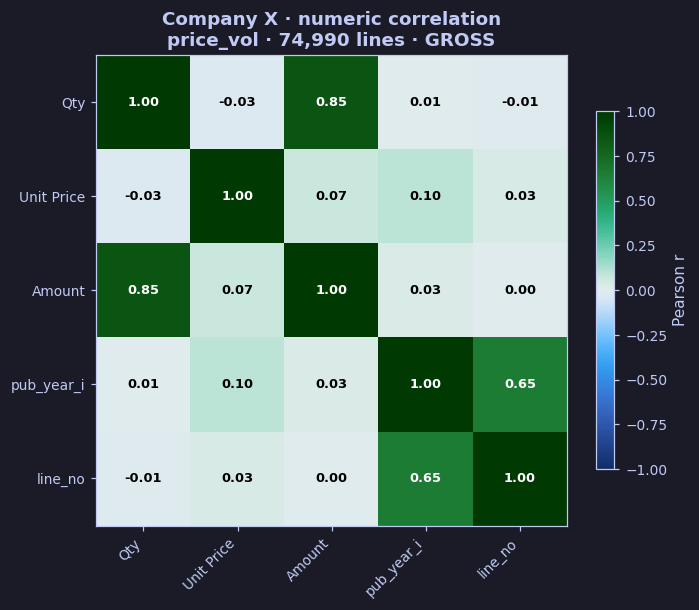

Amount ~ Qty × Unit Price residual check: 0.01


In [16]:
# ── 5.1  Correlation heatmap · price_vol · GROSS ─────────────────────
# objective: a report figure that records a step correctly rejected
from matplotlib.colors import Normalize

num = q("price_vol")[["Qty", "Unit Price", "Amount", "pub_year_i", "line_no"]].astype("float64")
corr = num.corr(method="pearson")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap=DIV, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)

norm = Normalize(vmin=-1, vmax=1)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        rgba = im.cmap(norm(v))                       # luminance of the cell colour
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = "black" if luminance > 0.5 else "white"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                color=text_color, fontweight="bold")

ax.set_title(f"Company X · numeric correlation\nprice_vol · {POP_S['price_vol']} lines · GROSS")
fig.colorbar(im, ax=ax, shrink=0.75, label="Pearson r")
save_fig(fig, "f01_corr_price_vol")
plt.show()

print(f"Amount ~ Qty × Unit Price residual check: "
      f"{(num['Amount'] - num['Qty'] * num['Unit Price']).abs().max():,.2f}")

**Population** price_vol · **Basis** GROSS · **Frame** whole register

Pearson correlation is uninformative on this frame. `Amount` is the arithmetic product of `Qty` and `Unit Price`, and the residual printed above confirms the identity holds. The matrix therefore reports a **definitional** relationship, not an empirical one, and its coefficients carry no information about publishing behaviour.

Correlation would only become meaningful on **aggregated** series (monthly units against monthly median price, at title or genre grain), where the identity no longer binds. That aggregation belongs to Q2 and is handled in §5.8. The figure is retained as evidence that the step was performed and its output correctly rejected.

### 5.2 Revenue composition

composition GROSS · 86,553 lines · 8,319 lines excluded vs the unfiltered register


saved → figures/f02_revenue_composition.png


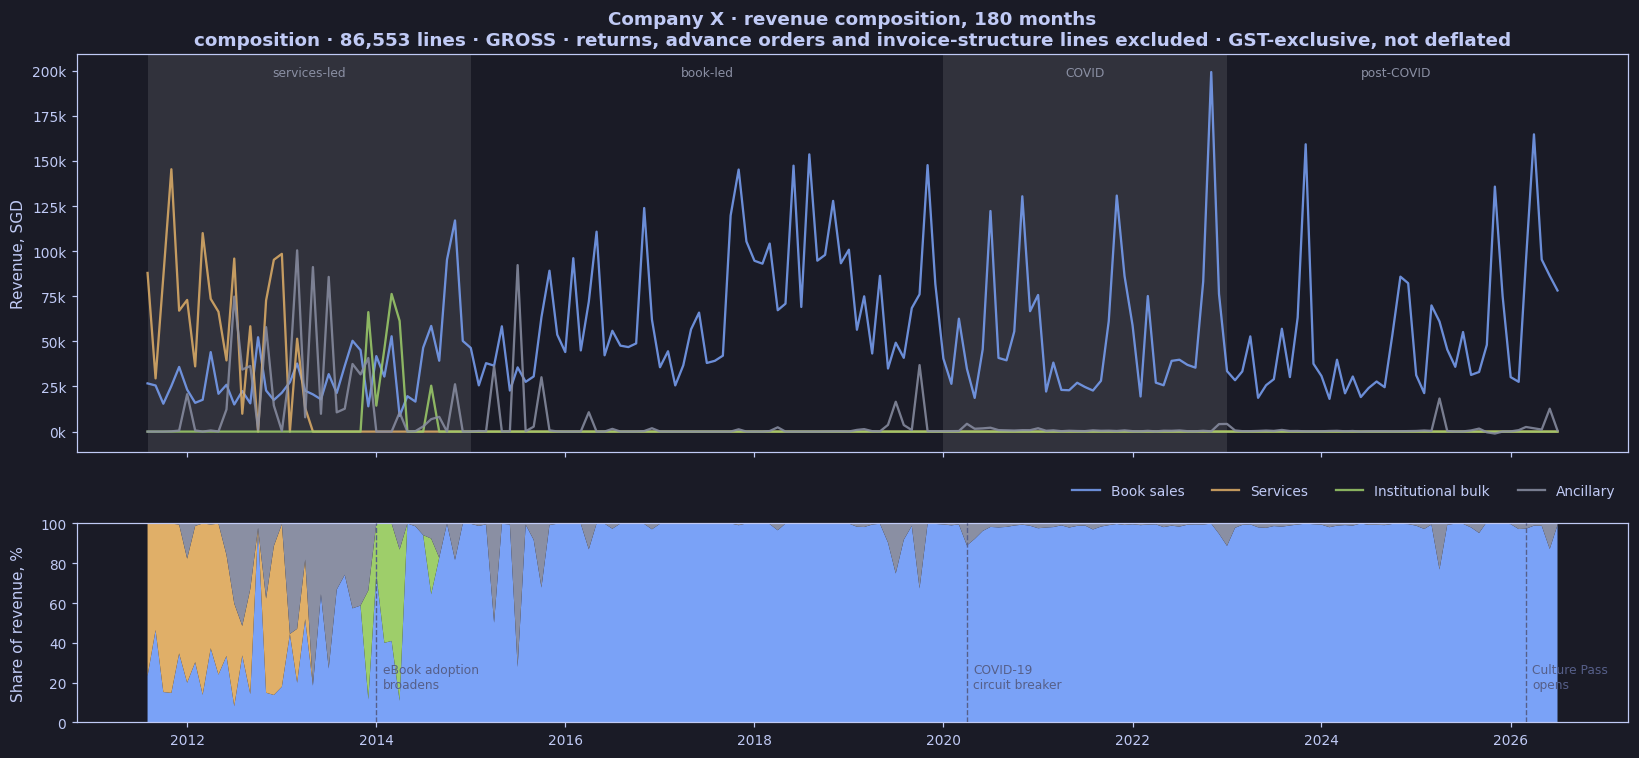

Ancillary              8.9% of GROSS revenue ·  2,939 lines (3.4% of lines)
Book sales            78.2% of GROSS revenue · 83,346 lines (96.3% of lines)
Institutional bulk     2.3% of GROSS revenue ·     96 lines (0.1% of lines)
Services              10.6% of GROSS revenue ·    172 lines (0.2% of lines)


In [17]:
# ── 5.2  Revenue composition over time · GROSS ──────────────────────────────
# objective: answers "what share of revenue is books vs services".
#
# FRAME. The `composition` filter is the whole register, which admits returns,
# client-excluded advance orders and null-Qty invoice-structure lines (GST and
# subtotals). None of those belong under a GROSS label (§4.2), so they are
# removed here.
COMPOSITION_GROSS = ('line_role != "return" '
                     'and client_excluded == False '
                     'and qty_sign != "null"')
c = sales.query(COMPOSITION_GROSS, engine="python").copy()

# Category comes from scope_reason, the contract's partition of the register.
SCOPE_LABELS = {"book": "Book sales", "book_rescued_isbn": "Book sales",
                "service": "Services", "institutional_bulk": "Institutional bulk",
                "non_book_type": "Ancillary"}
c["cat"] = c["scope_reason"].map(SCOPE_LABELS)
assert c["cat"].notna().all(), \
    f"unmapped scope_reason: {c.loc[c['cat'].isna(), 'scope_reason'].unique()}"

_drop = len(sales) - len(c)
print(f"composition GROSS · {len(c):,} lines · {_drop:,} lines excluded vs the unfiltered register")

comp = (c.groupby([c["ym_ts"], "cat"])["Amount"].sum()
          .unstack("cat").fillna(0.0)
          .reindex(columns=list(LABEL_COLOURS)))     # fixed draw order

tot = c.groupby("cat")["Amount"].sum()
assert abs(tot.sum() - sales["Amount"].sum()) / sales["Amount"].sum() > 0.005, \
    "the GROSS correction had no effect: is the query string being applied?"

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

# ── Panel A: unstacked lines ──────────────────────────────────────────────────
ax = axes[0]
shade_eras(ax, label=True)
for col in comp.columns:
    ax.plot(comp.index, comp[col], color=LABEL_COLOURS[col], lw=1.5, alpha=0.85, label=col)
ax.set_ylabel("Revenue, SGD")
ax.yaxis.set_major_formatter(lambda x, _: f"{x/1000:,.0f}k")
ax.legend(loc="upper right", bbox_to_anchor=(1, -0.05), ncol=4, fontsize=9)
ax.set_title("Company X · revenue composition, 180 months\n"
             f"composition · {len(c):,} lines · GROSS · returns, advance orders and "
             "invoice-structure lines excluded · GST-exclusive, not deflated")

# ── Panel B: percentage stacked area ──────────────────────────────────────────
ax = axes[1]
share = comp.div(comp.sum(axis=1).replace(0, pd.NA), axis=0) * 100
ax.stackplot(share.index, *[share[k].fillna(0).values for k in share],
             colors=[LABEL_COLOURS[k] for k in share], linewidth=0)
ax.set_ylim(0, 100); ax.set_ylabel("Share of revenue, %")
mark_events(ax, y=0.30)
tidy_event_labels(ax)

fig.align_ylabels(axes)
save_fig(fig, "f02_revenue_composition")
plt.show()

for k in tot.index:
    n = (c["cat"] == k).sum()
    print(f"{k:<20} {tot[k]/tot.sum()*100:>5.1f}% of GROSS revenue · {n:>6,} lines "
          f"({n/len(c)*100:.1f}% of lines)")

### 5.3 Monthly units and revenue

saved → figures/f03_monthly_units_revenue.png


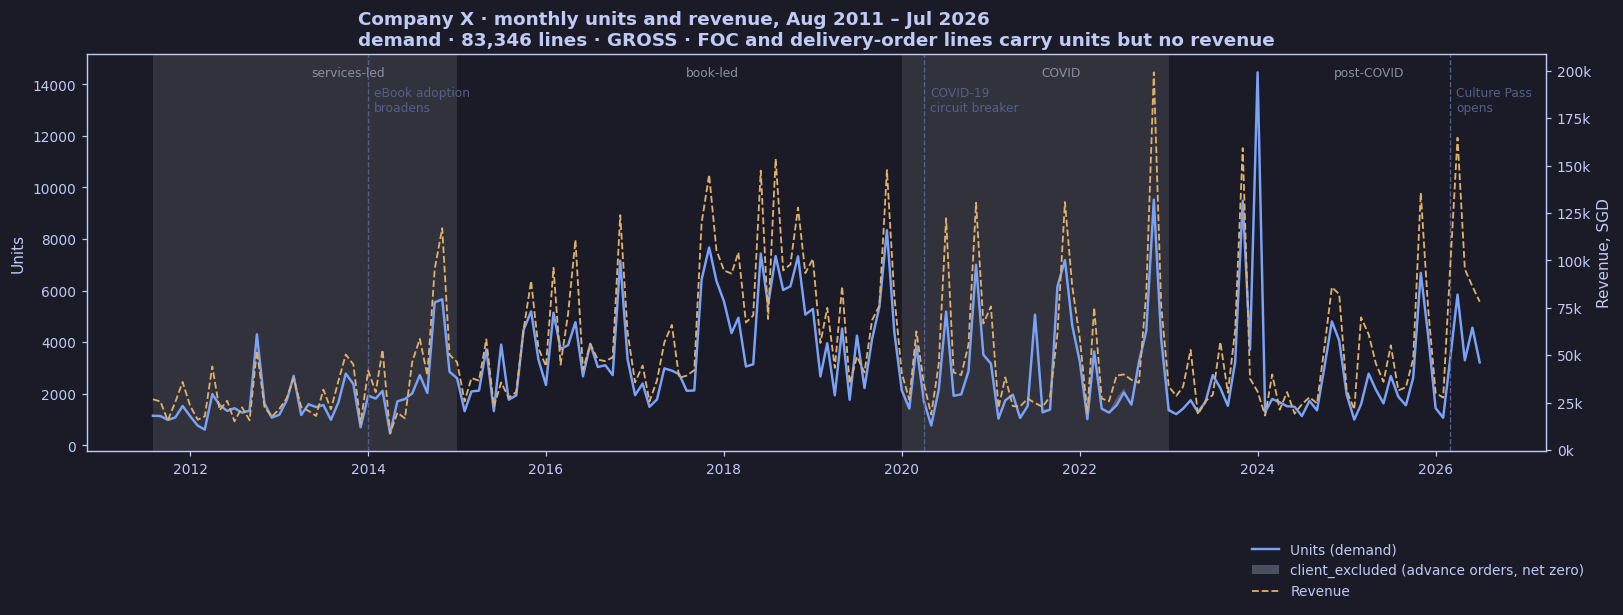

peak units  : 2024-01
peak revenue: 2022-11

── year-on-year % change, complete calendar years ──
       units YoY %  revenue YoY %
ym_ts                            
2013           8.2           18.2
2014          53.5           66.3
2015          10.3           -8.6
2016          35.7           50.8
2017         -10.6           -5.1
2018          60.8           60.8
2019         -25.8          -29.1
2020         -29.4          -20.6
2021           4.9          -17.7
2022           2.5           27.2
2023         -14.8          -20.6
2024          21.2          -19.5
2025         -19.6           40.5

2025 vs 2012: units +67% · revenue +119%


In [18]:
# ── 5.3  Monthly units and revenue · demand · GROSS ──────────────────
import matplotlib.patches as mpatches

d = q("demand")
m = d.groupby("ym_ts").agg(units=("Qty", "sum"), revenue=("Amount", "sum"))
assert len(m) == 180, f"expected 180 months, got {len(m)}: gap in the register"

incl = sales.query(f'{BOOK_SCOPE} and line_role != "return"',
                   engine="python").groupby("ym_ts")["Qty"].sum()

fig, ax = plt.subplots(figsize=(15, 6))
shade_eras(ax)
ax.plot(m.index, m["units"], color=CAT[0], lw=1.6, label="Units (demand)")
ax.fill_between(m.index, m["units"], incl.reindex(m.index).fillna(0),
                where=incl.reindex(m.index) > m["units"],
                color=GREY, alpha=0.45, lw=0,
                label="client_excluded (advance orders, net zero)")
ax.set_ylabel("Units")
ax2 = ax.twinx()
ax2.plot(m.index, m["revenue"], color=CAT[1], lw=1.2, ls="--", label="Revenue")
ax2.set_ylabel("Revenue, SGD")
ax2.yaxis.set_major_formatter(lambda x, _: f"{x/1000:,.0f}k")
ax2.grid(False)

mark_events(ax)
tidy_event_labels(ax)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="center left", bbox_to_anchor=(0.79, -0.30), fontsize=9)
ax.set_title("Company X · monthly units and revenue, Aug 2011 – Jul 2026\n"
             f"demand · {POP_S['demand']} lines · GROSS · FOC and delivery-order lines "
             "carry units but no revenue")

save_fig(fig, "f03_monthly_units_revenue")
plt.show()

print(f"peak units  : {m['units'].idxmax():%Y-%m}")
print(f"peak revenue: {m['revenue'].idxmax():%Y-%m}")

# Year-on-year change on complete calendar years (2012–2025)
annual = m.groupby(m.index.year).sum().loc[2012:2025]
yoy = (annual.pct_change() * 100).round(1).rename(columns=lambda c: f"{c} YoY %")
print("\n── year-on-year % change, complete calendar years ──")
print(yoy.dropna().to_string())
print(f"\n2025 vs 2012: units {(annual.loc[2025,'units']/annual.loc[2012,'units']-1)*100:+.0f}% · "
      f"revenue {(annual.loc[2025,'revenue']/annual.loc[2012,'revenue']-1)*100:+.0f}%")

### 5.4–5.5 Format and publishing arm

saved → figures/f04_05_mix_type_channel.png


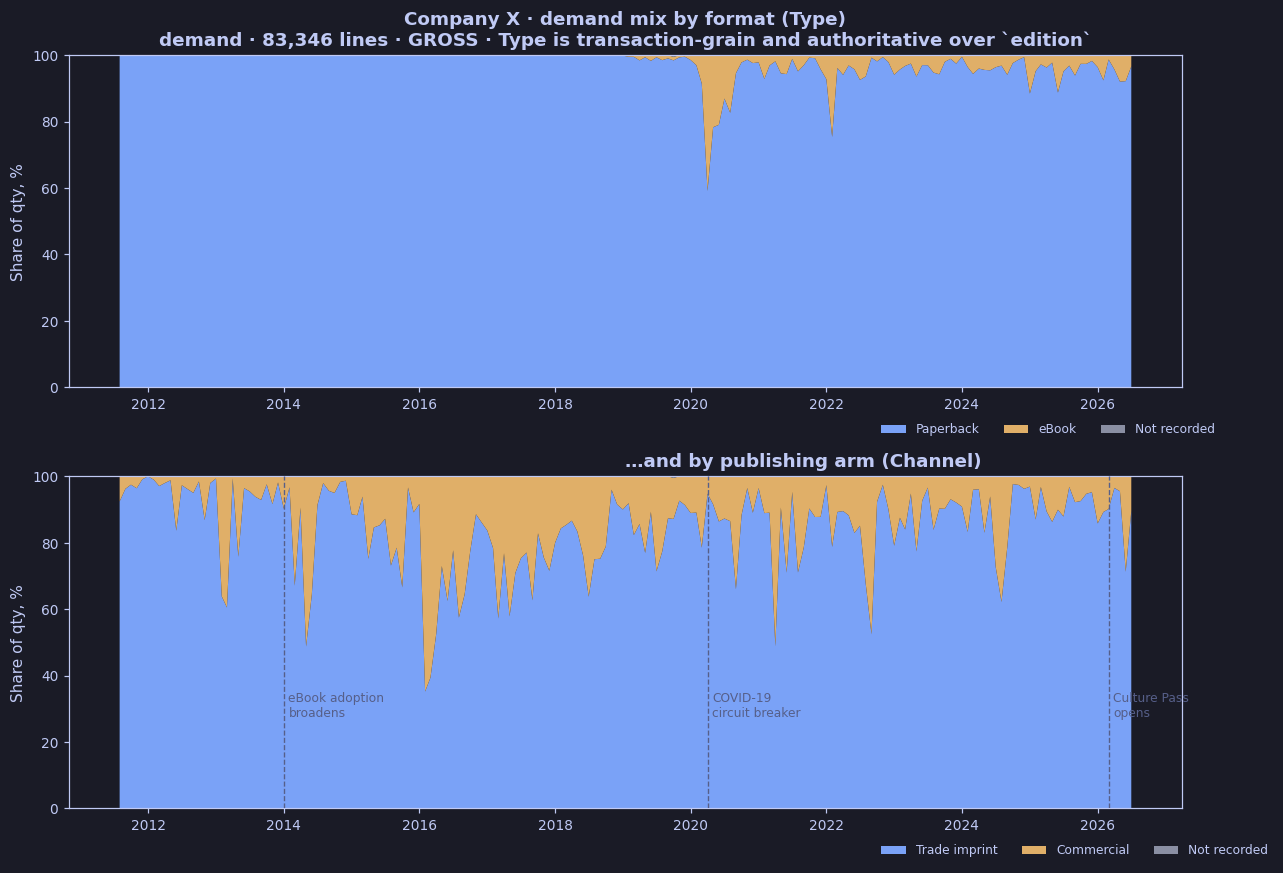


── Type · share of units, first vs last 24 months ──
              first_24 %  last_24 %  Δ share pp
Type                                           
Paperback          100.0       96.1        -3.9
eBook                0.0        3.9         3.9
Not recorded         0.0        0.0         0.0

── Channel · share of units, first vs last 24 months ──
               first_24 %  last_24 %  Δ share pp
Channel                                         
Trade imprint        91.1       91.0        -0.1
Commercial            8.9        9.0         0.1
Not recorded          0.0        0.0         0.0


In [19]:
# ── 5.4–5.5  Mix by Type (format) and Channel (publishing arm) ──────────────
# Modify: swap "Qty" for "Amount" in VAL to cut by revenue instead of units.
VAL = "Qty"
d = q("demand")

def mix_panel(ax, col, val=VAL, top=None):
    """Share-of-total stacked area for one dimension.
    Objective: shares, not levels (level change is already in §5.3).
    Modify: `top` caps categories and folds the rest into 'Other'.
    """
    piv = (d.groupby(["ym_ts", col], observed=True)[val].sum()
              .unstack(col).fillna(0.0))
    piv = piv.loc[:, piv.sum() > 0]                 # drop empty categories
    if top and piv.shape[1] > top:
        keep = piv.sum().nlargest(top).index
        piv = piv[keep].assign(Other=piv.drop(columns=keep).sum(axis=1))
    order = [c for c in piv.sum().sort_values(ascending=False).index
             if c != SENTINEL] + ([SENTINEL] if SENTINEL in piv else [])
    piv = piv[order]                                # sentinel pinned last
    sh = piv.div(piv.sum(axis=1).replace(0, pd.NA), axis=0) * 100
    cols = [GREY if c in (SENTINEL, "Other") else CAT[i]
            for i, c in enumerate(sh.columns)]
    ax.stackplot(sh.index, *[sh[c].fillna(0).values for c in sh],
                 labels=list(sh), colors=cols, linewidth=0)
    ax.set_ylim(0, 100); ax.set_ylabel(f"Share of {val.lower()}, %")
    ax.legend(loc="lower left", ncol=len(sh.columns), bbox_to_anchor=(0.72, -0.18), fontsize=8)
    return piv

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
p_type = mix_panel(axes[0], "Type")
axes[0].tick_params(labelbottom=True)
axes[0].set_title("Company X · demand mix by format (Type)\n"
                  f"demand · {POP_S['demand']} lines · GROSS · Type is transaction-grain "
                  "and authoritative over `edition`")
p_chan = mix_panel(axes[1], "Channel")
axes[1].set_title("…and by publishing arm (Channel)")
mark_events(axes[1], y=0.35)
tidy_event_labels(axes[1])

save_fig(fig, "f04_05_mix_type_channel")
plt.show()

for nm, p in [("Type", p_type), ("Channel", p_chan)]:
    print(f"\n── {nm} · share of units, first vs last 24 months ──")
    ends = pd.DataFrame({"first_24 %": p.head(24).sum() / p.head(24).sum().sum() * 100,
                         "last_24 %":  p.tail(24).sum() / p.tail(24).sum().sum() * 100})
    ends["Δ share pp"] = ends["last_24 %"] - ends["first_24 %"]
    print(ends.round(1).to_string())

### 5.6 Genre and family mix

saved → figures/f06_family_genre_mix.png


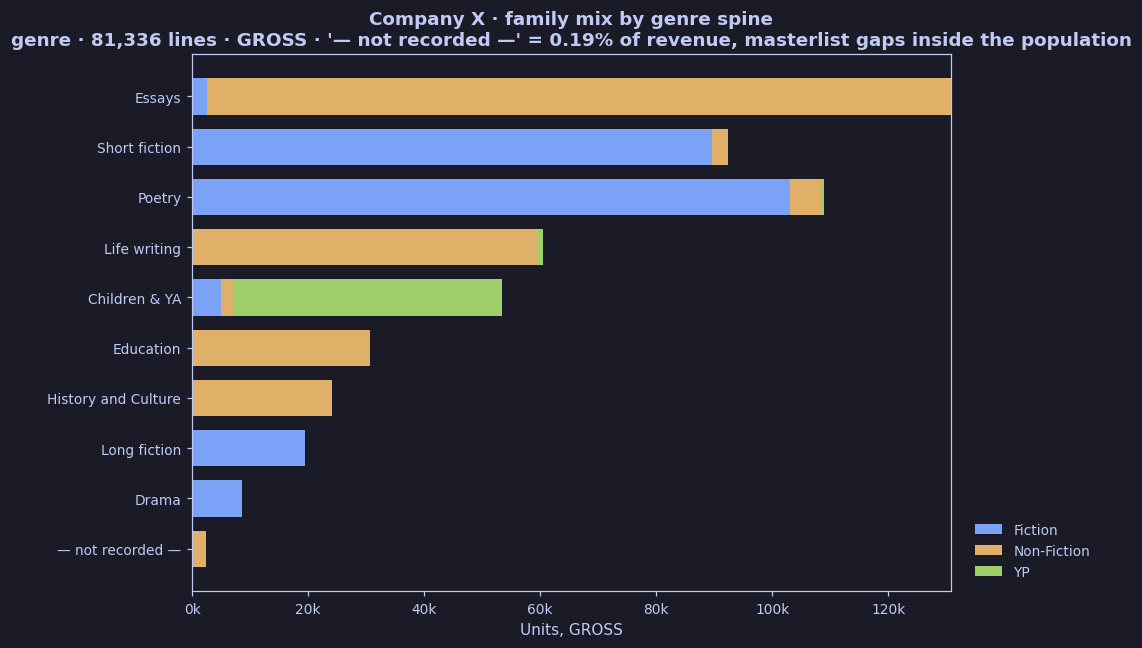

                        units  lines  units_%  revenue_%
subcat_family                                           
Essays               130794.0  21925     24.6       32.6
Short fiction         92375.0  14540     17.4       17.2
Poetry               108884.0  15315     20.5       16.5
Life writing          60564.0  10445     11.4       10.6
Children & YA         53453.0   4008     10.1        7.6
Education             30694.0   3657      5.8        5.4
History and Culture   24190.0   4155      4.6        4.7
Long fiction          19417.0   4683      3.7        3.5
Drama                  8639.0   2253      1.6        1.8
— not recorded —       2414.0    355      0.5        0.2


In [20]:
# ── 5.6a  Family × genre mix · genre · GROSS ──────────────────────────
# groups on the cleaned `genre_std`
g = q("genre")
fam = (g.groupby(["subcat_family", "genre_std"], observed=True)
         .agg(units=("Qty", "sum"), revenue=("Amount", "sum"), lines=("Qty", "size")))
assert len(g) == POP["genre"], f"genre population moved: {len(g):,}"

nr_share = (fam.loc["— not recorded —", "revenue"].sum() / fam["revenue"].sum() * 100
            if "— not recorded —" in fam.index.get_level_values(0) else 0.0)

piv = (fam["units"].unstack("genre_std").fillna(0.0))
piv = pin_sentinel(piv.assign(revenue=fam.groupby("subcat_family")["revenue"].sum()),
                   sort_col="revenue").drop(columns="revenue")
#      ^ rank families by revenue, pin '— not recorded —' last regardless

fig, ax = plt.subplots(figsize=(10, 6))
left = pd.Series(0.0, index=piv.index)
for i, gcol in enumerate(piv.columns):
    ax.barh(piv.index, piv[gcol], left=left, color=CAT[i], label=gcol, height=0.72)
    left += piv[gcol]
ax.invert_yaxis()
ax.set_xlabel("Units, GROSS")
ax.xaxis.set_major_formatter(lambda x, _: f"{x/1000:,.0f}k")
ax.legend(loc="lower right", bbox_to_anchor=(1.2, 0), fontsize=9)
ax.set_title("Company X · family mix by genre spine\n"
             f"genre · {POP_S['genre']} lines · GROSS · '— not recorded —' = "
             f"{nr_share:.2f}% of revenue, masterlist gaps inside the population")
save_fig(fig, "f06_family_genre_mix")
plt.show()

out = fam.groupby("subcat_family").sum()
out["units_%"]   = (out.units / out.units.sum() * 100).round(1)
out["revenue_%"] = (out.revenue / out.revenue.sum() * 100).round(1)
print(pin_sentinel(out, "revenue")[["units", "lines", "units_%", "revenue_%"]].to_string())

113 sub-category labels carry revenue · 33 reach 90% · remaining 80 carry 9.9%


saved → figures/f06c_subcategory_concentration.png


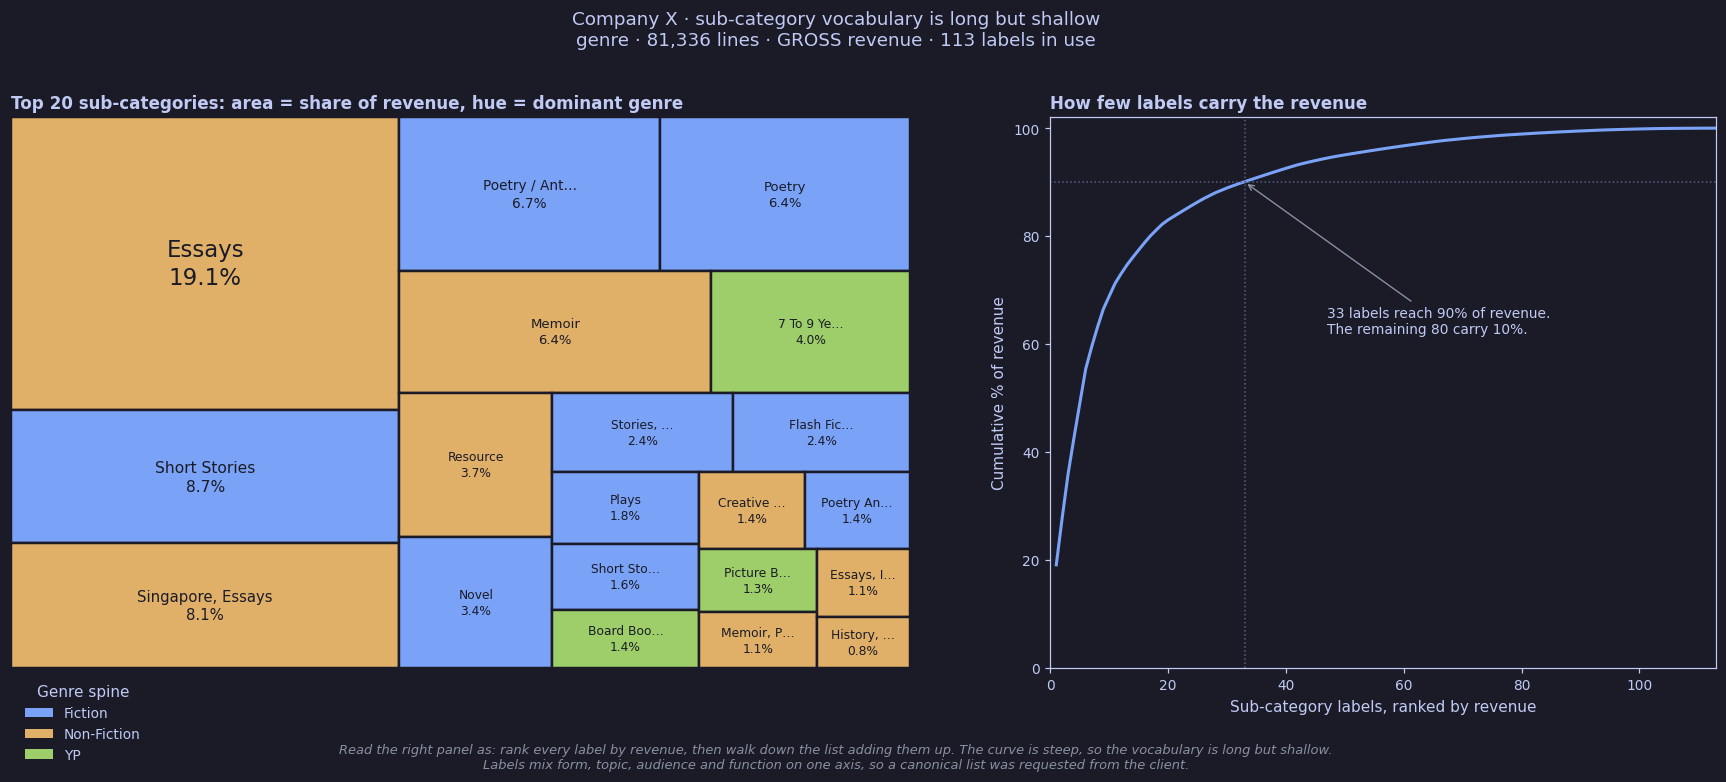

median label below the 90% line carries 0.09% of revenue


In [21]:
# ── 5.6b  Sub-category vocabulary concentration · genre · GROSS ─────────────
# Objective: not a segmentation figure but an ARGUMENT about the taxonomy. The
#   vocabulary is long and shallow, so a canonical list is worth the client's
#   time. Left: what the working labels are. Right: how few really matter.
import squarify
import matplotlib.patches as mpatches

GENRE_COLOURS = {"Fiction": CAT[0], "Non-Fiction": CAT[1], "YP": CAT[2]}

def draw_treemap(ax, sizes, labels, colors, sublabels=None,
                 min_frac=0.010, fs_max=10, fs_min=6.5):
    """Manual treemap with area-proportional label suppression."""
    order = pd.Series(sizes).sort_values(ascending=False).index
    sizes  = [sizes[i]  for i in order]
    labels = [labels[i] for i in order]
    colors = [colors[i] for i in order]
    subs   = [sublabels[i] for i in order] if sublabels else [None] * len(sizes)

    W = H = 100.0
    rects = squarify.squarify(squarify.normalize_sizes(sizes, W, H), 0, 0, W, H)
    total = float(sum(sizes))
    bg = mpl.rcParams["figure.facecolor"]

    for r, lab, col, sub, s in zip(rects, labels, colors, subs, sizes):
        ax.add_patch(plt.Rectangle((r["x"], r["y"]), r["dx"], r["dy"],
                                   facecolor=col, edgecolor=bg, linewidth=1.6))
        if s / total < min_frac:
            continue
        lum = mpl.colors.rgb_to_hsv(mpl.colors.to_rgb(col))[2]
        txt = bg if lum > 0.62 else FG
        fs  = min(fs_max, max(fs_min, (s / total) ** 0.28 * fs_max * 1.5))
        body = trunc(lab, max(10, int(r["dx"] / 2.1)))
        ax.text(r["x"] + r["dx"] / 2, r["y"] + r["dy"] / 2,
                body + (f"\n{sub}" if sub else ""),
                ha="center", va="center", fontsize=fs, color=txt, linespacing=1.3)
    ax.set_xlim(0, W); ax.set_ylim(0, H); ax.axis("off")
    ax.invert_yaxis()

# ── build ────────────────────────────────────────────────────────────────────
sc = (g.assign(sub_category=g["sub_category"].fillna("— not recorded —"))
        .groupby(["sub_category", "genre_std"], observed=True)
        .agg(revenue=("Amount", "sum"), units=("Qty", "sum"), lines=("Qty", "size"))
        .reset_index())
dom = (sc.sort_values("revenue", ascending=False)
         .drop_duplicates("sub_category").set_index("sub_category")["genre_std"])

lab = (sc.groupby("sub_category")["revenue"].sum()
         .sort_values(ascending=False))
lab = lab[lab > 0]
cum = lab.cumsum() / lab.sum() * 100
N90 = int((cum < 90).sum() + 1)
TOP = 20

print(f"{len(lab)} sub-category labels carry revenue · "
      f"{N90} reach 90% · remaining {len(lab) - N90} carry "
      f"{100 - cum.iloc[N90 - 1]:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(20, 6.5),
                         gridspec_kw={"width_ratios": [1.35, 1]})

# ── left: top-20 treemap, labelled with share of revenue ─────────────────────
top = lab.head(TOP)
draw_treemap(
    axes[0],
    sizes  = top.tolist(),
    labels = top.index.tolist(),
    colors = [GENRE_COLOURS.get(dom.get(k), GREY) for k in top.index],
    sublabels = [f"{v/lab.sum()*100:.1f}%" for v in top],
    min_frac = 0,                        # every box attempts a label
)

# Font size scales with box area, between 8pt and 15pt
rects = [p for p in axes[0].patches if isinstance(p, mpatches.Rectangle)]
if rects:
    areas = [r.get_width() * r.get_height() for r in rects]
    max_area = max(areas)
    for text_obj in axes[0].texts:
        tx, ty = text_obj.get_position()
        matching_rect = min(
            rects,
            key=lambda r: (r.get_x() + r.get_width()/2 - tx)**2 + (r.get_y() + r.get_height()/2 - ty)**2
        )
        area_ratio = matching_rect.get_width() * matching_rect.get_height() / max_area
        text_obj.set_fontsize(max(8, 15 * np.sqrt(area_ratio)))

handles = [mpatches.Patch(facecolor=c, label=k) for k, c in GENRE_COLOURS.items()]
axes[0].legend(handles=handles, loc="upper left", bbox_to_anchor=(0.01, -0.02),
               borderaxespad=0.0, frameon=False, fontsize=9, title="Genre spine")
axes[0].set_title(f"Top {TOP} sub-categories: area = share of revenue, hue = dominant genre",
                  fontsize=11, loc="left")

# ── right: cumulative revenue curve ──────────────────────────────────────────
ax = axes[1]
ax.plot(range(1, len(cum) + 1), cum.values, color=CAT[0], lw=2.0)
ax.axhline(90, color=RULE, ls=":", lw=1.0)
ax.axvline(N90, color=RULE, ls=":", lw=1.0)
ax.annotate(f"{N90} labels reach 90% of revenue.\n"
            f"The remaining {len(lab) - N90} carry {100 - cum.iloc[N90-1]:.0f}%.",
            xy=(N90, 90), xytext=(N90 + 14, 62), fontsize=9, color=FG,
            arrowprops=dict(arrowstyle="->", color=GREY, lw=0.9))
ax.set_xlabel("Sub-category labels, ranked by revenue")
ax.set_ylabel("Cumulative % of revenue")
ax.set_ylim(0, 102); ax.set_xlim(0, len(cum))
ax.set_title("How few labels carry the revenue", fontsize=11, loc="left")

fig.suptitle("Company X · sub-category vocabulary is long but shallow\n"
             f"genre · {POP_S['genre']} lines · GROSS revenue · {len(lab)} labels in use",
             y=1.03)
fig.text(0.5, -0.03,
         "Read the right panel as: rank every label by revenue, then walk down the "
         "list adding them up. The curve is steep, so the vocabulary is long but "
         "shallow.\nLabels mix form, topic, audience and function on one axis, so a "
         "canonical list was requested from the client.",
         ha="center", fontsize=8.5, color=GREY, style="italic")
fig.subplots_adjust(wspace=0.18)
save_fig(fig, "f06c_subcategory_concentration", tight=False)
plt.show()

print(f"median label below the 90% line carries {(lab.iloc[N90:] / lab.sum() * 100).median():.2f}% of revenue")

### 5.7 STL decomposition and autocorrelation

seasonal strength: 0.479 · trend strength: 0.331


saved → figures/f07a_stl_decomposition.png


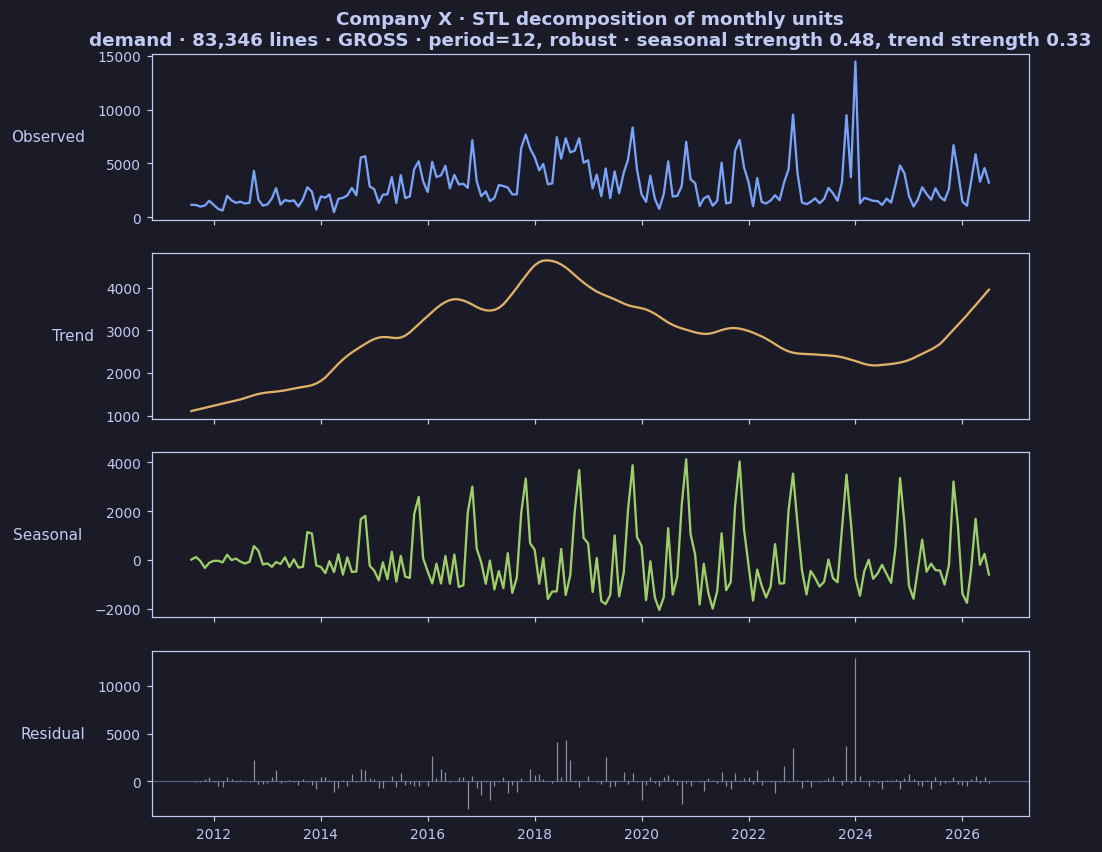

saved → figures/f07b_acf_pacf.png


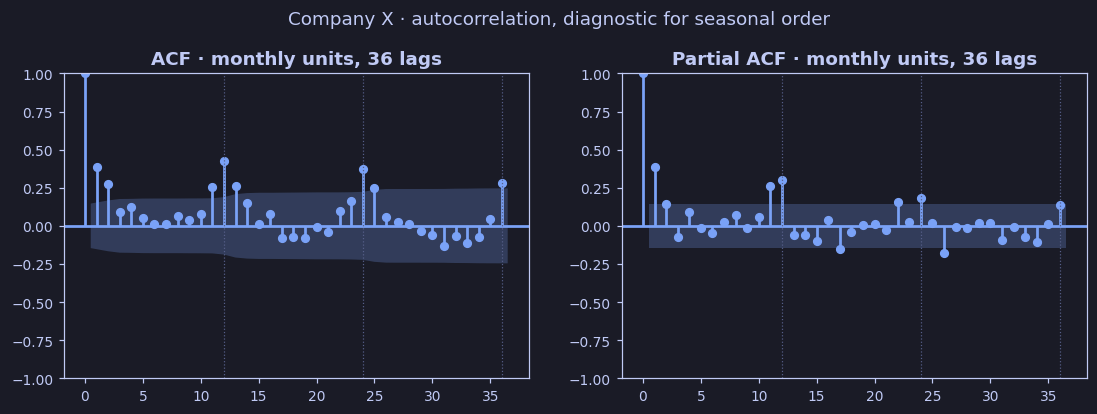


── month-of-year seasonal index, % of mean monthly units ──
ym_ts
1     -7.5
2    -38.3
3     -6.1
4    -19.6
5    -24.0
6    -26.1
7      8.9
8    -27.5
9    -21.7
10    46.9
11    91.3
12    23.4


In [22]:
# ── 5.7  Seasonal structure · demand · GROSS · 180 months ────────────
# objective: modelling diagnostic. Establishes whether a 12-month seasonal
#   component exists and how strong it is: the evidence for giving SARIMA a
#   seasonal order in notebook 3.
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

d = q("demand")
u = d.groupby("ym_ts")["Qty"].sum().asfreq("MS")
#                                    ^ asfreq makes the DatetimeIndex regular;
#                                      STL raises on an irregular index.
assert len(u) == 180 and u.notna().all(), \
       f"expected 180 unbroken months, got {len(u)} with {u.isna().sum()} gaps"

# ── a. fit ───────────────────────────────────────────────────────────────────
# period=12  : monthly data, annual cycle. Declared, not inferred.
# seasonal=7 : length of the seasonal smoother (odd, >= 7). Larger forces the
#              seasonal shape to stay more constant year to year.
# robust=True: downweights outliers such as one-off bulk orders, so they do
#              not drag the trend or leak into the seasonal component.
stl = STL(u, period=12, seasonal=7, robust=True).fit()

# Hyndman's strength measures (FPP3 §4.3). 0 = no structure, 1 = dominated.
F_seas  = max(0, 1 - stl.resid.var() / (stl.seasonal + stl.resid).var())
F_trend = max(0, 1 - stl.resid.var() / (stl.trend    + stl.resid).var())
print(f"seasonal strength: {F_seas:.3f} · trend strength: {F_trend:.3f}")

# ── b. plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
for ax, (series, name, col) in zip(axes, [
        (u,            "Observed", CAT[0]),
        (stl.trend,    "Trend",    CAT[1]),
        (stl.seasonal, "Seasonal", CAT[2]),
        (stl.resid,    "Residual", GREY)]):
    if name == "Residual":
        ax.axhline(0, color=RULE, lw=0.8)
        ax.vlines(series.index, 0, series.values, color=col, lw=0.8)
    else:
        ax.plot(series.index, series.values, color=col, lw=1.5)
    ax.set_ylabel(name, rotation=0, ha="right", va="center", labelpad=8)

axes[0].set_title("Company X · STL decomposition of monthly units\n"
                  f"demand · {POP_S['demand']} lines · GROSS · period=12, robust · "
                  f"seasonal strength {F_seas:.2f}, trend strength {F_trend:.2f}")
axes[-1].set_xlabel("")
fig.subplots_adjust(right=0.85)
save_fig(fig, "f07a_stl_decomposition", tight=False)
plt.show()

# ── c. ACF / PACF: SARIMA order identification, not a result ─────────────────
# Read: a spike at lag 12 (and 24) confirms annual seasonality and points at a
#   seasonal AR or MA term. Slow decay in the ACF points at differencing.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
plot_acf(u,  lags=36, ax=axes[0], color=CAT[0], vlines_kwargs={"colors": CAT[0]})
plot_pacf(u, lags=36, ax=axes[1], color=CAT[0], method="ywm",
          vlines_kwargs={"colors": CAT[0]})
for ax, t in zip(axes, ["ACF", "Partial ACF"]):
    ax.set_title(f"{t} · monthly units, 36 lags")
    for L in (12, 24, 36):
        ax.axvline(L, color=RULE, ls=":", lw=0.8)
fig.suptitle("Company X · autocorrelation, diagnostic for seasonal order", y=1.04)
save_fig(fig, "f07b_acf_pacf", tight=False)
plt.show()

print("\n── month-of-year seasonal index, % of mean monthly units ──")
print((stl.seasonal.groupby(stl.seasonal.index.month).mean() / u.mean() * 100)
      .round(1).to_string())

### 5.8 Decay profile

DECAY frame: 639 ISBNs × 121 months


saved → figures/f08_decay_profile.png


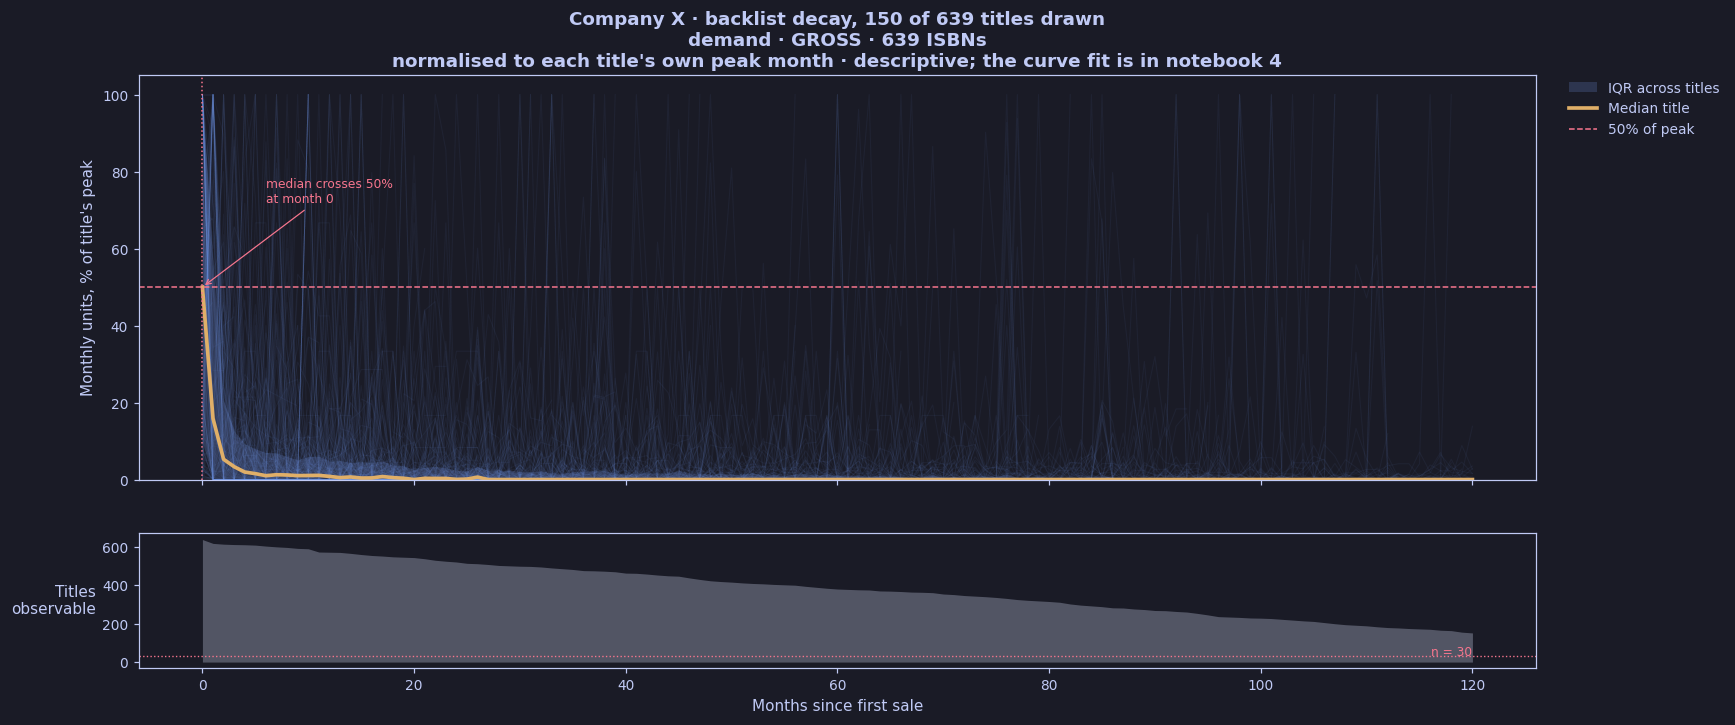


median % of peak at months 0/6/12/24/36/60: [50.0, 1.0, 0.8, 0.0, 0.0, 0.0]
titles observable at those months: [639, 605, 573, 522, 477, 381]


In [23]:
# ── 5.8  Title lifecycle · demand · GROSS · per isbn_key ────────────────────
# objective: descriptive view of how each title's monthly units fall from its
#   own peak. The curve fit is in notebook 4.
d = q("demand").dropna(subset=["isbn_key"]).copy()
DECAY_N = d["isbn_key"].nunique()     # named, never typed into the caption

# ── a. months since first sale, per ISBN ─────────────────────────────────────
# Integer month index avoids Period arithmetic: (Period - Period) returns an
# offset object, not an int, and breaks groupby downstream.
d["mi"] = d["ym"].dt.year * 12 + d["ym"].dt.month
by = d.groupby(["isbn_key", "mi"])["Qty"].sum().reset_index()
by["m0"] = by.groupby("isbn_key")["mi"].transform("min")
by["msf"] = by["mi"] - by["m0"]                       # months since first sale

# Dense 0..max grid per ISBN: a month with no sales is zero. Without this the
# median is computed only over months a title actually sold in, which flatters
# the tail badly.
grid = (by.set_index(["isbn_key", "msf"])["Qty"]
          .unstack("msf").reindex(columns=range(0, by["msf"].max() + 1))
          .fillna(0.0))

peak = grid.max(axis=1)
DECAY = grid.div(peak, axis=0) * 100                  # % of that title's peak
DECAY = DECAY[peak > 0]

# Observability mask: a title first sold in 2024 has no month-30 observation.
# Distinguish "sold nothing" (0) from "not yet observable" (NaN).
span = (d.groupby("isbn_key")["mi"].max() - d.groupby("isbn_key")["mi"].min())
obs  = pd.DataFrame({m: span >= m for m in DECAY.columns}).reindex(DECAY.index)
DECAY = DECAY.where(obs)

MAX_M = 120                                            # 10 years; beyond this
DECAY = DECAY.loc[:, :MAX_M]                           #   fewer than 30 titles
n_obs = DECAY.notna().sum()
med   = DECAY.median()
q1, q3 = DECAY.quantile(0.25), DECAY.quantile(0.75)
print(f"DECAY frame: {DECAY.shape[0]} ISBNs × {DECAY.shape[1]} months")

# ── b. plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(20, 7), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})
ax = axes[0]
sample = DECAY.sample(min(150, len(DECAY)), random_state=7)
for _, row in sample.iterrows():
    ax.plot(row.index, row.values, color=CAT[0], alpha=0.06, lw=0.7)
ax.fill_between(med.index, q1, q3, color=CAT[0], alpha=0.20, lw=0,
                label="IQR across titles")
ax.plot(med.index, med.values, color=CAT[1], lw=2.4, label="Median title")
ax.axhline(50, color=NEG, ls="--", lw=1.0, label="50% of peak")

half = med[med <= 50]
if len(half):
    h = half.index[0]
    ax.axvline(h, color=NEG, ls=":", lw=1.0)
    ax.annotate(f"median crosses 50%\nat month {h}", xy=(h, 50),
                xytext=(h + 6, 72), fontsize=8, color=NEG,
                arrowprops=dict(arrowstyle="->", color=NEG, lw=0.8))
ax.set_ylim(0, 105); ax.set_ylabel("Monthly units, % of title's peak")
ax.set_title(f"Company X · backlist decay, {len(sample)} of {DECAY_N} titles drawn\n"
             f"demand · GROSS · {DECAY.shape[0]} ISBNs\nnormalised to each "
             "title's own peak month · descriptive; the curve fit is in notebook 4")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0,
          frameon=False, fontsize=9)

ax = axes[1]                       # censoring: the honesty panel
ax.fill_between(n_obs.index, n_obs.values, color=GREY, alpha=0.5, lw=0)
ax.set_ylabel("Titles\nobservable", rotation=0, ha="right", va="center")
ax.set_xlabel("Months since first sale")
ax.axhline(30, color=NEG, ls=":", lw=0.9)
ax.text(MAX_M, 32, "n = 30", ha="right", fontsize=8, color=NEG)
fig.subplots_adjust(right=0.76)
save_fig(fig, "f08_decay_profile", tight=False)
plt.show()

print(f"\nmedian % of peak at months 0/6/12/24/36/60: "
      f"{[round(float(med.get(m, np.nan)), 1) for m in (0, 6, 12, 24, 36, 60)]}")
print(f"titles observable at those months: "
      f"{[int(n_obs.get(m, 0)) for m in (0, 6, 12, 24, 36, 60)]}")

### 5.9 Gross-to-net

null Amount inside net_revenue: 9,804 lines


FOC: 8,514 lines · 69,672 units · price coverage 98.8% · counterfactual value 16.1% of gross revenue
saved → figures/f09_gross_to_net.png


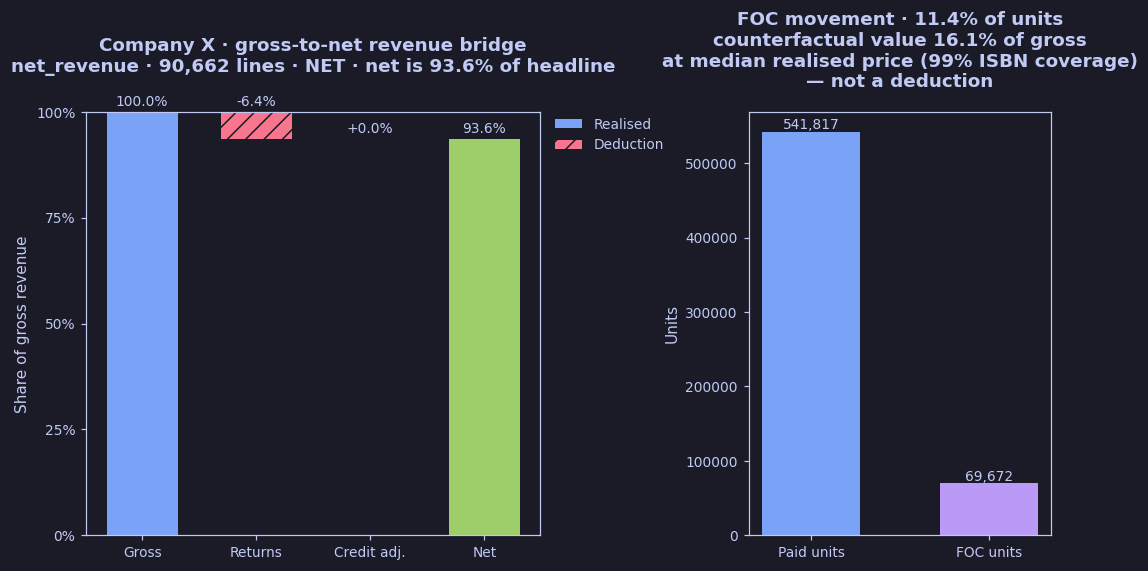

returns     -6.40% of gross
credit adj. +0.00% of gross
net         93.60% of gross


In [24]:
# ── 5.9  Gross-to-net exposure · net_revenue · NET ───────────────────
# objective: Q3. Two panels because FOC carries NO revenue (§3.8-D): a single
#   waterfall with an FOC bar would draw a zero-height bar and imply a
#   deduction that does not exist.
n = q("net_revenue")
print(f"null Amount inside net_revenue: {n['Amount'].isna().sum():,} lines")

m_ret = n["is_return"].eq(True)
m_cn  = n["is_credit_adj"].eq(True) & ~m_ret
m_gr  = ~m_ret & ~m_cn
#       ^ mutually exclusive by construction. The assert below proves it.

gross   = n.loc[m_gr,  "Amount"].sum()
returns = n.loc[m_ret, "Amount"].sum()
credits = n.loc[m_cn,  "Amount"].sum()
net     = n["Amount"].sum()
assert abs((gross + returns + credits) - net) < 0.01, "bridge does not close"
# ↑ can fail, and would if the three masks overlapped or missed lines.
#   This assert is the entire defensibility of the figure.

steps = [("Gross", gross, CAT[0]), ("Returns", returns, NEG),
         ("Credit adj.", credits, NEG), ("Net", net, CAT[2])]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [3, 2]})

ax, run = axes[0], 0.0
for i, (lab, val, col) in enumerate(steps):
    if lab in ("Gross", "Net"):
        ax.bar(i, val, color=col, width=0.62,
               label="Realised" if lab == "Gross" else None)
        run = val
    else:
        ax.bar(i, val, bottom=run, color=col, width=0.62,
               hatch="//", edgecolor=mpl.rcParams["figure.facecolor"], lw=0,
               label="Deduction" if lab == "Returns" else None)
        run += val
    ax.text(i, max(run, run - val) + gross * 0.015,
            f"{val/gross*100:+.1f}%" if lab not in ("Gross", "Net")
            else f"{val/gross*100:.1f}%", ha="center", fontsize=9, color=FG)
ax.set_xticks(range(len(steps))); ax.set_xticklabels([s[0] for s in steps])
ax.set_ylabel("Share of gross revenue")
ax.set_yticks([gross * p for p in (0, .25, .5, .75, 1)])
ax.yaxis.set_major_formatter(lambda x, _: f"{x/gross*100:.0f}%")
ax.set_title("Company X · gross-to-net revenue bridge\n"
             f"net_revenue · {POP_S['net_revenue']} lines · NET · net is {net/gross*100:.1f}% "
             "of headline", pad=28, wrap=True)

# ── panel B: FOC in UNITS, with a counterfactual value ───────────────────────
# FOC has no Amount, so it is valued at the median realised price for the same
# ISBN. Counterfactual: forgone revenue, explicitly not a deduction.
px = q("price_vol").groupby("isbn_key")["Unit Price"].median()
foc = sales[sales["is_foc"] & sales["book_scope"]].copy()
foc["px"] = foc["isbn_key"].map(px)
cov = foc["px"].notna().mean()
foc_units = foc["Qty"].sum()
foc_value = (foc["Qty"] * foc["px"]).sum()
print(f"FOC: {len(foc):,} lines · {foc_units:,.0f} units · price coverage {cov:.1%} "
      f"· counterfactual value {foc_value/gross*100:.1f}% of gross revenue")

ax = axes[1]
paid_units = n.loc[m_gr, "Qty"].sum()
ax.bar(["Paid units", "FOC units"], [paid_units, foc_units],
       color=[CAT[0], CAT[3]], width=0.55)
for i, v in enumerate([paid_units, foc_units]):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9, color=FG)
ax.set_ylabel("Units")
ax.set_title(f"FOC movement · {foc_units/(paid_units+foc_units)*100:.1f}% of units\n"
             f"counterfactual value {foc_value/gross*100:.1f}% of gross\nat median realised "
             f"price ({cov:.0%} ISBN coverage)\n— not a deduction", pad=18, wrap=True)

axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0,
               frameon=False, fontsize=9)
#              ^ hatch is the semantic carrier (deduction vs realised), so the
#                key belongs on the bridge panel, not the units panel.
fig.subplots_adjust(right=0.80, wspace=0.55)
save_fig(fig, "f09_gross_to_net", tight=False)
plt.show()

print(f"returns     {returns/gross*100:+.2f}% of gross")
print(f"credit adj. {credits/gross*100:+.2f}% of gross")
print(f"net         {net/gross*100:.2f}% of gross")

### 5.10 Return rate over time

saved → figures/f10_return_rate.png


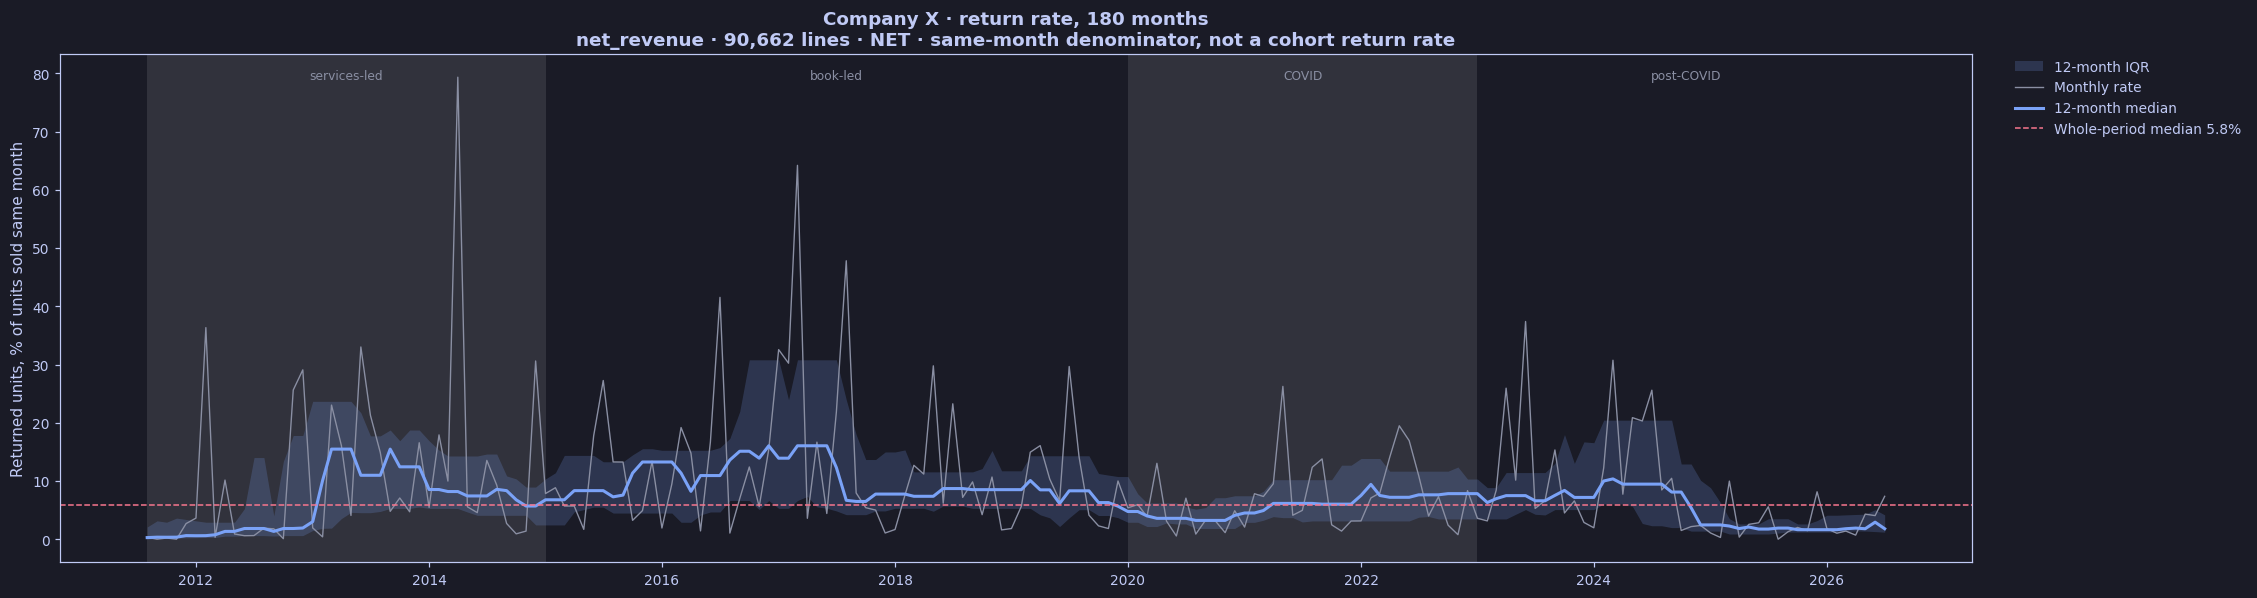

count    180.00
mean       9.87
std       11.42
min        0.00
25%        2.34
50%        5.83
75%       13.30
max       79.35

── 10 highest months ──
ym_ts
2014-04-01    79.4
2017-03-01    64.2
2017-08-01    47.8
2016-07-01    41.5
2023-06-01    37.4
2012-02-01    36.3
2013-06-01    33.0
2017-01-01    32.6
2024-03-01    30.7
2014-12-01    30.6


In [25]:
# ── 5.10  Return rate · monthly · NET denominator ───────────────────────────
# objective: Q3's stability question. The denominator is units sold in the same
#   calendar month, not a cohort rate: a June return against a March sale is
#   booked in June.
n = q("net_revenue")
sold = n.loc[~n["is_return"].eq(True)].groupby("ym_ts")["Qty"].sum()
retd = n.loc[ n["is_return"].eq(True)].groupby("ym_ts")["Qty"].sum().abs()
rate = (retd / sold).reindex(sold.index).fillna(0.0) * 100

roll = rate.rolling(12, center=True, min_periods=6)
med, lo, hi = roll.median(), roll.quantile(0.25), roll.quantile(0.75)
#                             ^ IQR band, not ±2SD: the series is right-skewed
#                               by occasional bulk returns, so SD overstates it.

fig, ax = plt.subplots(figsize=(25, 6))
shade_eras(ax)
ax.fill_between(rate.index, lo, hi, color=CAT[0], alpha=0.20, lw=0, label="12-month IQR")
ax.plot(rate.index, rate.values, color=GREY, lw=0.9, label="Monthly rate")
ax.plot(med.index, med.values, color=CAT[0], lw=2.0, label="12-month median")
ax.axhline(rate.median(), color=NEG, ls="--", lw=1.0,
           label=f"Whole-period median {rate.median():.1f}%")

ax.set_ylabel("Returned units, % of units sold same month")
ax.set_title("Company X · return rate, 180 months\n"
             f"net_revenue · {POP_S['net_revenue']} lines · NET · same-month denominator, "
             "not a cohort return rate")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0,
          frameon=False, fontsize=9)
fig.subplots_adjust(right=0.82)
save_fig(fig, "f10_return_rate", tight=False)
plt.show()

print(rate.describe().round(2).to_string())
print("\n── 10 highest months ──")
print(rate.nlargest(10).round(1).to_string())

### 5.11 Culture Pass

saved → figures/f11_culture_pass.png


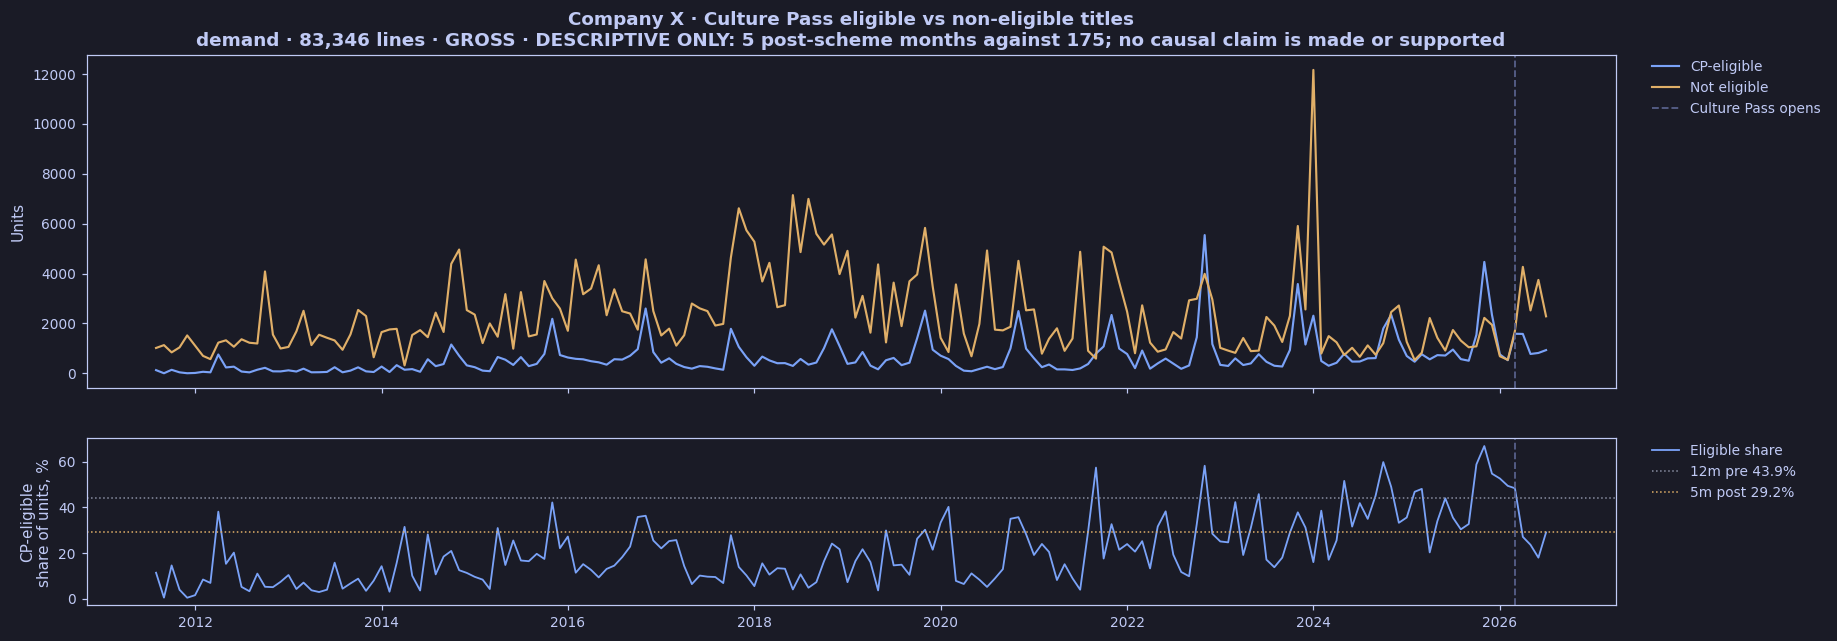

CP-eligible share · 12m before 43.9% · 5m after 29.2% · Δ -14.7pp
post-scheme months observed: 5


In [26]:
# ── 5.11  Culture Pass · demand · GROSS · DESCRIPTIVE ONLY ──────────────────
# objective: context. Five post-scheme months (Mar–Jul 2026) against 175 before;
#   this figure cannot support a causal claim, and the caption says so.
d = q("demand")
CP_START = pd.Timestamp("2026-03-01")
piv = (d.groupby(["ym_ts", d["culture_pass"].map({True: "CP-eligible",
                                                  False: "Not eligible"})])["Qty"]
         .sum().unstack().fillna(0.0))
share = piv["CP-eligible"] / piv.sum(axis=1) * 100

fig, axes = plt.subplots(2, 1, figsize=(20, 6.5), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
ax = axes[0]
for i, c in enumerate(piv.columns):
    ax.plot(piv.index, piv[c], color=CAT[i], lw=1.4, label=c)
ax.axvline(CP_START, color=RULE, ls="--", lw=1.2, label="Culture Pass opens")
ax.set_ylabel("Units")
ax.set_title("Company X · Culture Pass eligible vs non-eligible titles\n"
             f"demand · {POP_S['demand']} lines · GROSS · DESCRIPTIVE ONLY: 5 post-scheme "
             "months against 175; no causal claim is made or supported")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0,
          frameon=False, fontsize=9)

ax = axes[1]
ax.plot(share.index, share.values, color=CAT[0], lw=1.2, label="Eligible share")
ax.axvline(CP_START, color=RULE, ls="--", lw=1.2)
pre_m = share[:CP_START].tail(12).mean(); post_m = share[CP_START:].mean()
ax.axhline(pre_m,  color=GREY,   ls=":", lw=1.0, label=f"12m pre {pre_m:.1f}%")
ax.axhline(post_m, color=CAT[1], ls=":", lw=1.0, label=f"5m post {post_m:.1f}%")
ax.set_ylabel("CP-eligible\nshare of units, %")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0,
          frameon=False, fontsize=9)

fig.subplots_adjust(right=0.82)
save_fig(fig, "f11_culture_pass", tight=False)
plt.show()

print(f"CP-eligible share · 12m before {pre_m:.1f}% · 5m after {post_m:.1f}% "
      f"· Δ {post_m - pre_m:+.1f}pp")
print(f"post-scheme months observed: {(share.index >= CP_START).sum()}")

### 5.12 Customer × family mix

top 12 customers = 64.2% of genre-population revenue, from 663 customers


saved → figures/f12_customer_family_mix.png


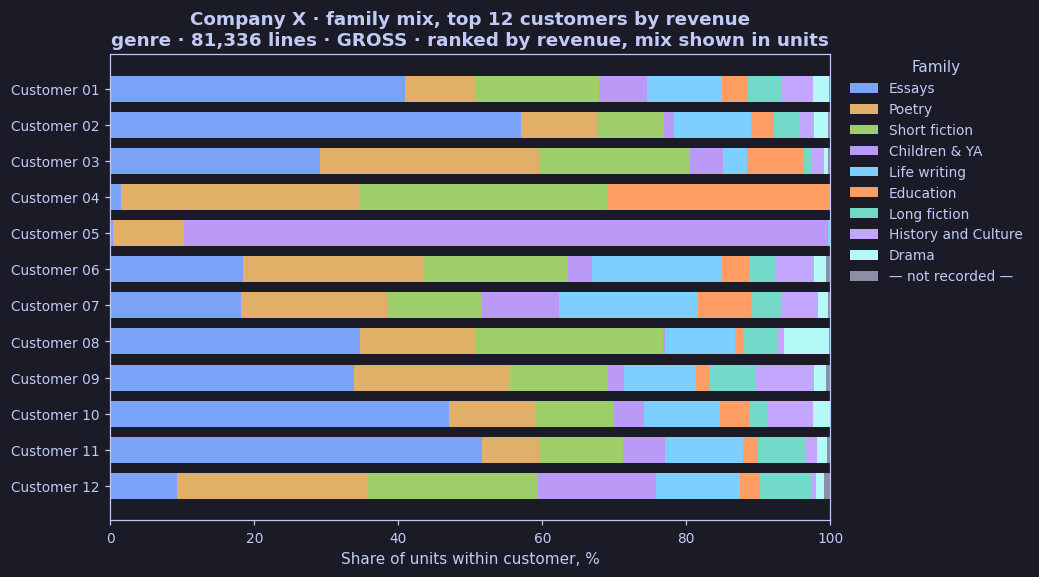

In [27]:
# ── 5.12  Family mix by customer · genre · GROSS ─────────────────────
# objective: requested by the client. Customers are ranked by revenue and
#   shown as 'Customer 01'…; `Name` is never read by this notebook.
# Modify: TOP_N. Beyond ~12 the axis labels stop being legible at slide scale.
TOP_N = 12
g = q("genre")

rev = g.groupby("Customer ID")["Amount"].sum().nlargest(TOP_N)
sub = g.loc[g["Customer ID"].isin(rev.index), ["Customer ID", "subcat_family", "Qty"]]
guard_pii(sub)                       # only the columns the figure needs
piv = (sub.groupby(["Customer ID", "subcat_family"], observed=True)["Qty"]
          .sum().unstack().fillna(0.0).reindex(rev.index))
sh  = piv.div(piv.sum(axis=1), axis=0) * 100
order = [c for c in sh.sum().sort_values(ascending=False).index
         if c != "— not recorded —"] + \
        (["— not recorded —"] if "— not recorded —" in sh else [])
sh = sh[order]

print(f"top {TOP_N} customers = {rev.sum()/g['Amount'].sum()*100:.1f}% of "
      f"genre-population revenue, from {g['Customer ID'].nunique()} customers")
# ↑ this concentration number is the finding. The chart is the detail.

labels = [f"Customer {i+1:02d}" for i in range(len(rev))]
fig, ax = plt.subplots(figsize=(11, 5.5))
left = pd.Series(0.0, index=sh.index)
for i, fam_name in enumerate(sh.columns):
    col = GREY if fam_name == "— not recorded —" else CAT[i % len(CAT)]
    ax.barh(labels, sh[fam_name], left=left, color=col, label=fam_name, height=0.72)
    left += sh[fam_name]
ax.invert_yaxis(); ax.set_xlim(0, 100)
ax.set_xlabel("Share of units within customer, %")
ax.set_title(f"Company X · family mix, top {TOP_N} customers by revenue\n"
             f"genre · {POP_S['genre']} lines · GROSS · ranked by revenue, "
             "mix shown in units")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0,
          frameon=False, fontsize=9, title="Family")
fig.subplots_adjust(right=0.72)      # the widest key in the set needs the margin
save_fig(fig, "f12_customer_family_mix", tight=False)
plt.show()

### 5.13 Republish lifecycle

saved → figures/f13_republish_cases.png


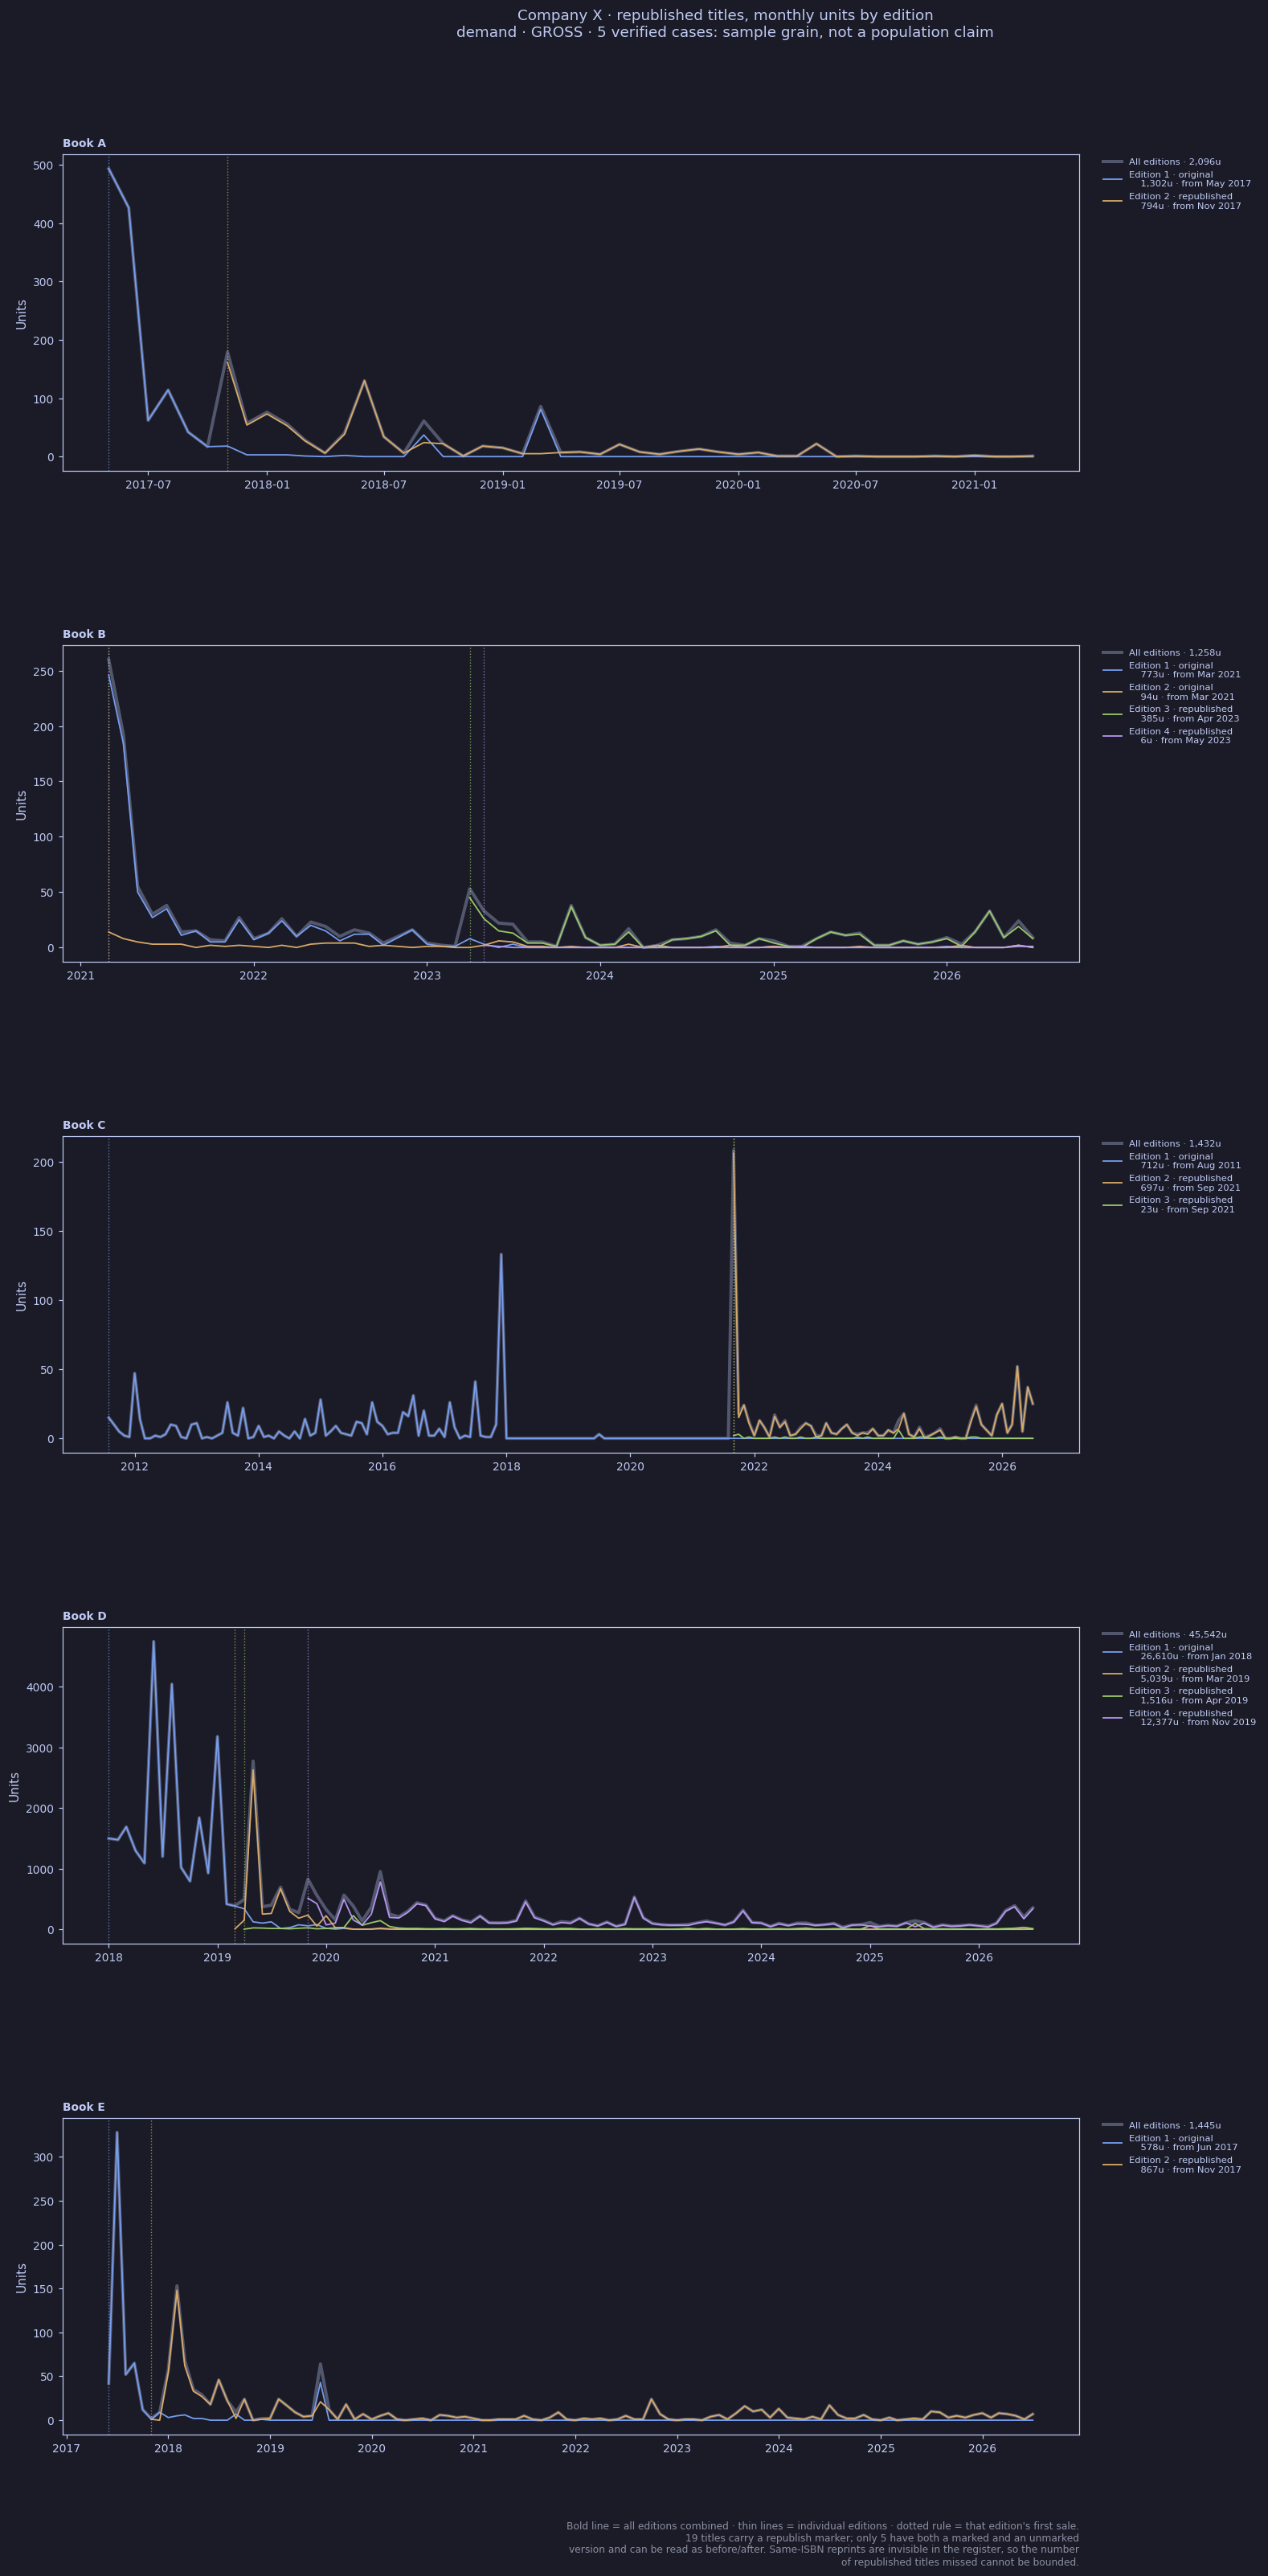

In [28]:
# ── 5.13  Republish · verified base titles · demand · GROSS ─────────────────
# objective: Q2's secondary question, not a population claim. Titles carrying a
#   republish marker are only readable as before/after when BOTH a marked and
#   an unmarked version exist (§3.5). Same-ISBN reprints leave no trace in the
#   register, so the number of republished titles missed cannot be bounded.
VERIFIED = survives.index.tolist()          # the base titles found in §3.5
MARK = r"(?:new cover|second edition|2nd edition|revised|reissue|reprint|new edition)"

d = q("demand").copy()
d["t_norm"] = (d["title"].astype(str).str.replace(r"\s+", " ", regex=True)
                 .str.strip().str.lower())
d["base"] = (d["t_norm"].str.replace(MARK, "", case=False, regex=True)
               .str.replace(r"[\(\)\[\],\-–]", " ", regex=True)
               .str.replace(r"\s+", " ", regex=True).str.strip())
d["marked"] = d["t_norm"].str.contains(MARK, case=False, regex=True)

n_marked = d.loc[d["title"].astype(str).str.contains(MARK, case=False, regex=True),
                 "t_norm"].nunique()                 # same rule as scan B (§3.5)
fig, axes = plt.subplots(len(VERIFIED), 1, figsize=(20, 6 * len(VERIFIED)), sharex=False)

for idx, (ax, base) in enumerate(zip(axes, VERIFIED)):
    sub = d[d["base"] == base]

    # ── total across all editions ────────────────────────────────────────
    span = pd.date_range(sub["ym_ts"].min(), sub["ym_ts"].max(), freq="MS")
    total = sub.groupby("ym_ts")["Qty"].sum().reindex(span).fillna(0.0)
    ax.plot(total.index, total.values, color=FG, lw=2.6, alpha=0.35, zorder=1,
            label=f"All editions · {sub['Qty'].sum():,.0f}u")

    # ── one thin unbroken line per edition, starting at its first sale ──────
    for i, (isbn, grp) in enumerate(sub.groupby("isbn_key", observed=True)):
        first_date = grp["ym_ts"].min()
        edition_span = pd.date_range(first_date, sub["ym_ts"].max(), freq="MS")
        s = grp.groupby("ym_ts")["Qty"].sum().reindex(edition_span).fillna(0.0)
        mk = grp["marked"].iloc[0]
        col = CAT[i % len(CAT)]
        ax.plot(s.index, s.values, color=col, lw=1.2, alpha=0.95, zorder=2,
                label=f"Edition {i + 1} · {'republished' if mk else 'original'}\n"
                      f"    {grp['Qty'].sum():,.0f}u · from {first_date:%b %Y}")
        ax.axvline(first_date, color=col, ls=":", lw=0.9, alpha=0.7, zorder=0)

    ax.set_title(f"Book {chr(65 + idx)}", fontsize=9, loc="left")
    ax.set_ylabel("Units")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0,
              frameon=False, fontsize=7.5)

fig.suptitle("Company X · republished titles, monthly units by edition\n"
             f"demand · GROSS · {len(VERIFIED)} verified cases: sample grain, "
             "not a population claim", y=0.995)
fig.subplots_adjust(right=0.70, hspace=0.55, top=0.94, bottom=0.08)
fig.text(0.70, 0.03,
    "Bold line = all editions combined · thin lines = individual editions · dotted rule = "
    "that edition's first sale.\n"
    f"{n_marked} titles carry a republish marker; only {len(VERIFIED)} have both a "
    "marked and an unmarked\nversion and can be read as before/after. Same-ISBN reprints "
    "are invisible in the register, so the number\nof republished titles missed cannot be bounded.",
    fontsize=8, color=GREY, ha="right", va="bottom")
save_fig(fig, "f13_republish_cases", tight=False)
plt.show()

<a id="conclusion"></a>
## 6. Conclusion

<b>Answering the Research Question</b>
> Demand is concentrated and seasonal. Titles sell hard at launch and then taper into a long, thin tail. FOC copies, not returns, are the larger gap between books moved and revenue earned.

**Demand mix (Q1)**
* Books earn 78.2% of GROSS revenue. Services earn 10.6% from only 0.2% of lines: a small, high-value line of business.
* Paperback still carries 96.1% of units over the last 24 months; eBooks grew from 0% to 3.9%. The trade-imprint share of units is stable at about 91%.
* Essays are 24.6% of units but 32.6% of revenue, the only family that out-earns its volume by a wide margin. Of 113 sub-category labels, 33 carry 90% of revenue, which is the case for a shorter canonical list.
* The top 12 of 663 customers account for 64.2% of genre revenue: a concentration risk worth monitoring.
* Complete years 2012 to 2025: units +67%, revenue +119%, with year-on-year swings from −29% to +61%.

**Seasonality (Q4 diagnostic)**
* Seasonal strength is 0.48 and trend strength 0.33: moderate structure. October to December is the peak (November runs 91% above an average month) and February is the trough (38% below).

**Lifecycle (Q2)**
* By month 6 after first sale, the median title sells about 1% of its peak month. Notebook 4 tests whether that is a cliff or a slow decay.

**Revenue exposure (Q3)**
* Net revenue is 93.6% of gross. Returns remove 6.4%; credit adjustments net to about zero.
* FOC copies are 11.4% of units, worth 16.1% of gross revenue at median realised prices: about 2.5 times the returns leak, and not visible in any revenue report.
* The median monthly return rate is 5.8% of units sold, with occasional bulk-return spikes.

**Context**
* The Culture Pass-eligible share of units fell from 43.9% (12 months before launch) to 29.2% (5 months after). With five post-launch months this is descriptive only.

##### So what?
* **Plan stock and print runs around October to December**, and treat February as the natural low.
* **Review FOC policy before returns policy**: FOC is the larger lever.
* **Consolidate the sub-category vocabulary** so that genre segmentation becomes reliable.

##### Limitations
* Invoices record shipments, returns and credit notes, not reading; "demand" means trade movement.
* Monetary values are GST-exclusive and not deflated.
* Only five months of data follow the Culture Pass launch.